In [ ]:
from pathlib import Path
import inspect
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import re

## 데이터 EDA

In [ ]:
# 프로젝트 루트 설정
current = Path.cwd().resolve()

PROJECT_ROOT = next(
    (
        path
        for path in [current, *current.parents]
        if (path / "src").is_dir()
    ),
    None
)

if PROJECT_ROOT is None:
    raise FileNotFoundError("프로젝트의 src 폴더를 찾을 수 없습니다.")

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))


In [ ]:
# XJTU-SY Features 데이터 경로 지정 

DATA_ROOT = PROJECT_ROOT / "DATA" / "features" / "XJTU_SY_total_features.csv"

In [ ]:
# 통계량 csv 저장 경로 지정 

OUTPUT_DIR_STATS = PROJECT_ROOT / "results" / "eda"
OUTPUT_DIR_STATS.mkdir(parents=True, exist_ok=True)

In [ ]:
# 그래프 추출 경로 지정

OUTPUT_DIR_FIGURE = PROJECT_ROOT / "figures" / "eda" 

folder_names = [
    "03_distribution",
    "04_time_series",
    "05_feature_relationship",
]

for folder_name in folder_names:
    (OUTPUT_DIR_FIGURE / folder_name).mkdir(
        parents=True,
        exist_ok=True,
    )


## 1. 구조 및 데이터 품질 확인
#### 데이터 크기와 컬럼

In [ ]:
df = pd.read_csv(DATA_ROOT)

print("행, 열:", df.shape)
print("\n컬럼:")
print(df.columns.tolist())

df.info()

행, 열: (9216, 14)

컬럼:
['timestamp', 'bearing', 'condition', 'rpm', 'load_kn', 'fault_element', 'horizontal_rms', 'horizontal_kurtosis', 'horizontal_peak', 'horizontal_crest_factor', 'vertical_rms', 'vertical_kurtosis', 'vertical_peak', 'vertical_crest_factor']
<class 'pandas.DataFrame'>
RangeIndex: 9216 entries, 0 to 9215
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   timestamp                9216 non-null   int64  
 1   bearing                  9216 non-null   str    
 2   condition                9216 non-null   int64  
 3   rpm                      9216 non-null   int64  
 4   load_kn                  9216 non-null   int64  
 5   fault_element            9216 non-null   str    
 6   horizontal_rms           9216 non-null   float64
 7   horizontal_kurtosis      9216 non-null   float64
 8   horizontal_peak          9216 non-null   float64
 9   horizontal_crest_factor  9216 non-null   flo

#### 결측치 확인

In [ ]:
missing_summary = pd.DataFrame({
    "missing_count": df.isna().sum(),
    "missing_ratio": df.isna().mean() * 100
})

missing_summary

,missing_count,missing_ratio
timestamp,0,0.0
bearing,0,0.0
condition,0,0.0
rpm,0,0.0
load_kn,0,0.0
fault_element,0,0.0
horizontal_rms,0,0.0
horizontal_kurtosis,0,0.0
horizontal_peak,0,0.0
horizontal_crest_factor,0,0.0


#### 중복 확인

In [ ]:
print("전체 중복 행 수:", df.duplicated().sum())

전체 중복 행 수: 0


#### 베어링별 데이터 개수 및 시간 순서 확인

In [ ]:
bearing_check = (
    df.groupby("bearing")
    .agg(
        count=("bearing", "size"),
        timestamp_sorted=("timestamp", lambda x: x.is_monotonic_increasing)
    )
    .reset_index()
)

bearing_check

,bearing,count,timestamp_sorted
0,Bearing1_1,123,True
1,Bearing1_2,161,True
2,Bearing1_3,158,True
3,Bearing1_4,122,True
4,Bearing1_5,52,True
5,Bearing2_1,491,True
6,Bearing2_2,161,True
7,Bearing2_3,533,True
8,Bearing2_4,42,True
9,Bearing2_5,339,True


## 2. 기초 통계량 확인
#### 베어링별 기초 통계값

In [ ]:
feature_cols = [
    "horizontal_rms",
    "horizontal_kurtosis",
    "horizontal_peak",
    "horizontal_crest_factor",
    "vertical_rms",
    "vertical_kurtosis",
    "vertical_peak",
    "vertical_crest_factor",
]

bearing_stats = (
    df
    .groupby("bearing")[feature_cols]
    .agg(["mean", "median", "std", "min", "max"])
)

display(bearing_stats)

horizontal_rms                                          \
                     mean    median       std       min       max   
bearing                                                             
Bearing1_1       1.679512  0.806864  1.298084  0.563890  7.268278   
Bearing1_2       2.222551  2.541183  1.291880  0.562025  6.964491   
Bearing1_3       1.045055  0.689869  0.860764  0.488500  4.450550   
Bearing1_4       0.440728  0.410349  0.153063  0.370712  2.051909   
Bearing1_5       2.062988  0.993282  1.955797  0.933921  9.216745   
Bearing2_1       0.534038  0.363816  0.703790  0.338133  7.160751   
Bearing2_2       1.897976  1.552186  1.385532  0.474434  7.664384   
Bearing2_3       1.545165  0.567838  1.423420  0.365319  5.054544   
Bearing2_4       1.668078  0.632068  1.840582  0.511443  6.330619   
Bearing2_5       3.274729  2.022682  2.667702  0.895537  9.894413   
Bearing3_1       0.589991  0.495595  0.502310  0.435831  9.140705   
Bearing3_2       1.215057  1.044718  0.499762  0.746782  5.748715   
Bearing3_3       0.817065  0.558790  0.937115  0.478818  4.959022   
Bearing3_4       0.656237  0.466656  0.852594  0.376757  6.429379   
Bearing3_5       4.276045  4.360909  1.417615  0.699666  7.021225   

           horizontal_kurtosis                                             \
                          mean    median        std       min         max   
bearing                                                                     
Bearing1_1            4.950768  4.818709   0.815895  3.071352    8.766069   
Bearing1_2            3.763244  3.632904   0.595099  2.857697    6.496164   
Bearing1_3            3.532259  3.418490   0.550585  2.948443    5.420898   
Bearing1_4            4.284867  3.048894  12.795259  2.944285  144.437493   
Bearing1_5            3.052866  3.032080   0.133931  2.658788    3.449986   
Bearing2_1            3.122629  3.004200   0.501193  2.904791    6.634052   
Bearing2_2            3.284050  3.039913   0.773971  2.294223    7.845237   
Bearing2_3            3.657135  3.523434   0.605920  2.942845    6.797979   
Bearing2_4            3.540035  3.459118   0.518248  2.725170    4.784757   
Bearing2_5            3.242068  3.378639   0.466806  2.311909    4.287915   
Bearing3_1            3.047919  3.040130   0.126360  2.528388    5.195805   
Bearing3_2            3.320726  3.188199   0.312401  2.789421    8.149624   
Bearing3_3            3.097801  3.012267   0.355444  2.910914    6.754519   
Bearing3_4            3.369311  3.165660   0.684061  2.918460    7.859149   
Bearing3_5            2.826428  2.844102   0.247572  2.339159    3.544837   

            ... vertical_peak                                             \
            ...          mean     median        std       min        max   
bearing     ...                                                            
Bearing1_1  ...      6.163309   3.941905   3.921194  2.327442  22.906256   
Bearing1_2  ...     13.098517  15.055633   7.583663  2.544808  37.526214   
Bearing1_3  ...      5.716098   3.288841   5.727017  1.910818  28.505158   
Bearing1_4  ...      3.212365   2.640820   4.284066  2.148747  49.773812   
Bearing1_5  ...      8.191190   3.559309   9.562815  2.949715  53.180351   
Bearing2_1  ...      3.010354   2.097631   3.802930  1.726913  34.909892   
Bearing2_2  ...      8.490622   7.563639   5.417956  1.754975  20.128238   
Bearing2_3  ...      9.849409   5.718589   8.012781  2.289581  34.047532   
Bearing2_4  ...     10.940650   6.545210   9.460232  3.463721  37.226117   
Bearing2_5  ...     11.325459   7.378578   7.607074  4.798639  45.517230   
Bearing3_1  ...      2.616317   2.190399   2.210602  1.735413  35.087132   
Bearing3_2  ...      6.536142   6.030011   1.774562  4.270649  26.473582   
Bearing3_3  ...      4.786909   3.099573   5.977852  2.429926  35.294449   
Bearing3_4  ...      3.596777   2.733684   3.619935  2.034056  32.564700   
Bearing3_5  ...     24.634111  24.878567  11.133638  3.509283  46.511412   

           v

#### 베어링별 기초 통계값 확장

In [ ]:
# 베어링별 기초 통계값 확장

bearing_stats_detail = (
    df
    .groupby("bearing")[feature_cols]
    .agg([
        "mean",
        "median",
        "std",
        "min",
        "max",
        lambda x: x.quantile(0.25),
        lambda x: x.quantile(0.75),
        "skew"
    ])
)

bearing_stats_detail

grouped = df.groupby("bearing")[feature_cols]

mean_df = grouped.mean()
median_df = grouped.median()
std_df = grouped.std()
min_df = grouped.min()
max_df = grouped.max()

q1_df = grouped.quantile(0.25)
q3_df = grouped.quantile(0.75)

iqr_df = q3_df - q1_df
cv_df = std_df / mean_df

skew_df = grouped.skew()

In [ ]:
# 사분위수 및 IQR

grouped = df.groupby("bearing")[feature_cols]

q1_df = grouped.quantile(0.25)
q3_df = grouped.quantile(0.75)
iqr_df = q3_df - q1_df

print("Q1")
display(q1_df)

print("Q3")
display(q3_df)

print("IQR")
display(iqr_df)

Q1


,horizontal_rms,horizontal_kurtosis,horizontal_peak,horizontal_crest_factor,vertical_rms,vertical_kurtosis,vertical_peak,vertical_crest_factor
bearing,,,,,,,,
Bearing1_1,0.758763,4.638961,6.340992,6.323334,0.632696,2.926742,3.303969,4.620176
Bearing1_2,0.721550,3.428858,5.265987,5.576867,0.962115,2.961575,4.758942,4.127677
Bearing1_3,0.519473,3.023937,2.256191,4.345809,0.534194,2.967664,2.389890,4.087752
Bearing1_4,0.390572,3.007394,1.664406,4.196265,0.567574,2.990894,2.436191,4.131755
Bearing1_5,0.971027,2.991904,4.180449,4.035109,0.783004,2.955172,3.373301,3.887131
Bearing2_1,0.355360,2.979327,1.485968,4.104562,0.473948,2.982595,1.983529,4.105044
Bearing2_2,0.508321,2.921824,2.534568,4.248737,0.480648,2.654748,2.116251,3.312116
Bearing2_3,0.502631,3.110222,2.669871,4.593843,0.771450,2.940263,3.753078,4.182626
Bearing2_4,0.591477,3.226822,3.919509,5.072025,0.712924,3.366560,5.098221,4.688281


Q3


,horizontal_rms,horizontal_kurtosis,horizontal_peak,horizontal_crest_factor,vertical_rms,vertical_kurtosis,vertical_peak,vertical_crest_factor
bearing,,,,,,,,
Bearing1_1,2.939927,5.276775,19.137877,8.893275,2.102481,3.271953,9.295893,5.659649
Bearing1_2,3.128657,3.935884,21.401274,7.569494,3.955373,3.338638,18.305933,5.207969
Bearing1_3,1.295163,3.882784,9.086934,6.731249,1.552912,3.090787,6.625238,4.571893
Bearing1_4,0.475780,3.166618,2.406865,5.259109,0.693172,3.075869,3.156558,4.706039
Bearing1_5,2.124087,3.073988,8.981639,4.529936,2.588434,3.047474,9.423950,4.449151
Bearing2_1,0.378700,3.029292,1.685697,4.501981,0.500599,3.055305,2.217048,4.493139
Bearing2_2,2.897644,3.449305,13.627934,6.100319,4.144714,3.016658,13.558078,4.238995
Bearing2_3,3.115755,3.941039,15.015697,5.847307,4.069005,3.404913,17.818463,5.461797
Bearing2_4,2.672091,3.867446,10.943976,7.399517,2.647676,3.992993,11.576471,8.289308


IQR


,horizontal_rms,horizontal_kurtosis,horizontal_peak,horizontal_crest_factor,vertical_rms,vertical_kurtosis,vertical_peak,vertical_crest_factor
bearing,,,,,,,,
Bearing1_1,2.181164,0.637814,12.796885,2.569940,1.469786,0.345211,5.991924,1.039473
Bearing1_2,2.407107,0.507026,16.135287,1.992627,2.993258,0.377062,13.546991,1.080292
Bearing1_3,0.775690,0.858848,6.830743,2.385440,1.018718,0.123123,4.235348,0.484142
Bearing1_4,0.085208,0.159224,0.742459,1.062844,0.125597,0.084975,0.720367,0.574284
Bearing1_5,1.153060,0.082084,4.801190,0.494827,1.805430,0.092302,6.050649,0.562020
Bearing2_1,0.023340,0.049966,0.199729,0.397419,0.026651,0.072710,0.233519,0.388095
Bearing2_2,2.389323,0.527481,11.093366,1.851581,3.664066,0.361909,11.441827,0.926879
Bearing2_3,2.613124,0.830817,12.345827,1.253464,3.297555,0.464649,14.065385,1.279171
Bearing2_4,2.080614,0.640624,7.024467,2.327492,1.934752,0.626432,6.478250,3.601027


In [ ]:
# 특징값 변동성 및 분포 비대칭

mean_df = grouped.mean()
std_df = grouped.std()

# 변동계수 CV
cv_df = std_df / mean_df

# 왜도
skew_df = grouped.skew()

print("CV")
display(cv_df)


print("Skewness")
display(skew_df)

CV


,horizontal_rms,horizontal_kurtosis,horizontal_peak,horizontal_crest_factor,vertical_rms,vertical_kurtosis,vertical_peak,vertical_crest_factor
bearing,,,,,,,,
Bearing1_1,0.772894,0.164802,0.612821,0.232635,0.713534,0.091420,0.636216,0.163603
Bearing1_2,0.581260,0.158134,0.582280,0.201857,0.672880,0.129925,0.578971,0.199946
Bearing1_3,0.823654,0.155873,0.903542,0.280429,1.058306,0.052815,1.001910,0.098957
Bearing1_4,0.347296,2.986151,1.886817,0.438858,0.275203,0.682588,1.333617,0.330816
Bearing1_5,0.948041,0.043871,1.034025,0.096749,1.101967,0.075301,1.167451,0.109189
Bearing2_1,1.317866,0.160503,1.619785,0.100506,1.204342,0.105929,1.263283,0.083640
Bearing2_2,0.730005,0.235676,0.656496,0.340976,0.701387,0.087988,0.638111,0.167671
Bearing2_3,0.921209,0.165682,0.902452,0.202009,0.884130,0.120244,0.813529,0.252154
Bearing2_4,1.103415,0.146396,0.817368,0.319904,1.291716,0.172238,0.864686,0.313384


Skewness


,horizontal_rms,horizontal_kurtosis,horizontal_peak,horizontal_crest_factor,vertical_rms,vertical_kurtosis,vertical_peak,vertical_crest_factor
bearing,,,,,,,,
Bearing1_1,1.169123,0.959207,0.815075,1.008331,1.533103,1.243936,1.422606,0.807556
Bearing1_2,0.206969,1.541396,0.078136,0.738723,0.879811,0.955671,0.186462,1.451463
Bearing1_3,2.508987,0.953649,1.740172,1.050967,2.648504,-0.483831,2.546848,0.975272
Bearing1_4,9.788212,11.041236,10.755369,7.904839,9.029557,11.024946,10.784314,9.131502
Bearing1_5,1.987765,0.769183,2.279268,0.997457,2.195832,-1.790354,2.944043,-0.165301
Bearing2_1,5.546307,4.512474,6.302182,2.097745,4.756731,6.399359,5.212701,1.572689
Bearing2_2,0.910171,2.689171,0.856466,1.805705,-0.008019,-0.160393,-0.007682,0.865510
Bearing2_3,0.820061,1.142843,0.921708,1.401545,0.941129,1.606579,0.997325,1.761055
Bearing2_4,1.384924,0.456444,1.526795,0.415609,1.756207,-0.199607,1.546141,-0.214231


In [ ]:
features = [
    "horizontal_rms",
    "horizontal_kurtosis",
    "horizontal_peak",
    "horizontal_crest_factor",
    "vertical_rms",
    "vertical_kurtosis",
    "vertical_peak",
    "vertical_crest_factor",
]

# Wide → Long
feature_long = df.melt(
    id_vars="bearing",
    value_vars=features,
    var_name="feature",
    value_name="value",
)

# 베어링 × 특징별 기초 통계량
bearing_stats = (
    feature_long
    .groupby(["bearing", "feature"])["value"]
    .agg(
        count="count",
        mean="mean",
        median="median",
        std="std",
        skewness="skew",
        min="min",
        q25=lambda x: x.quantile(0.25),
        q75=lambda x: x.quantile(0.75),
        max="max",
    )
    .reset_index()
)

# 변동계수 CV
bearing_stats["cv"] = bearing_stats["std"] / bearing_stats["mean"]

# 사분위수
bearing_stats["IQR"] = bearing_stats["q75"] - bearing_stats["q25"]


# 컬럼 순서 정리
bearing_stats = bearing_stats[
    [
        "bearing",
        "feature",
        "count",
        "mean",
        "median",
        "std",
        "cv",
        "min",
        "q25",
        "q75",
        "IQR",
        "max",
        "skewness"
    ]
]

# features 순서 정리 (같은 특징값 수평-수직으로 볼 수 있도록)
feature_order = [
    "horizontal_rms",
    "vertical_rms",
    "horizontal_kurtosis",
    "vertical_kurtosis",
    "horizontal_peak",
    "vertical_peak",
    "horizontal_crest_factor",
    "vertical_crest_factor",
]

bearing_stats["feature"] = pd.Categorical(
    bearing_stats["feature"],
    categories=feature_order,
    ordered=True
)

bearing_stats = (
    bearing_stats
    .sort_values(["bearing", "feature"])
    .reset_index(drop=True)
)

bearing_stats


,bearing,feature,count,mean,median,std,cv,min,q25,q75,IQR,max,skewness
0,Bearing1_1,horizontal_rms,123,1.679512,0.806864,1.298084,0.772894,0.563890,0.758763,2.939927,2.181164,7.268278,1.169123
1,Bearing1_1,vertical_rms,123,1.251946,0.650190,0.893306,0.713534,0.560471,0.632696,2.102481,1.469786,5.783524,1.533103
2,Bearing1_1,horizontal_kurtosis,123,4.950768,4.818709,0.815895,0.164802,3.071352,4.638961,5.276775,0.637814,8.766069,0.959207
3,Bearing1_1,vertical_kurtosis,123,3.156616,3.177877,0.288579,0.091420,2.715385,2.926742,3.271953,0.345211,4.370076,1.243936
4,Bearing1_1,horizontal_peak,123,11.636979,7.571578,7.131382,0.612821,2.529883,6.340992,19.137877,12.796885,35.597789,0.815075
...,...,...,...,...,...,...,...,...,...,...,...,...,...
115,Bearing3_5,vertical_kurtosis,114,2.730421,2.791334,0.257140,0.094176,2.268677,2.584519,2.899355,0.314836,3.328726,-0.417785
116,Bearing3_5,horizontal_peak,114,16.682863,16.531926,5.776066,0.346228,3.110564,14.608362,20.481554,5.873191,27.879930,-0.448491
117,Bearing3_5,vertical_peak,114,24.634111,24.878567,11.133638,0.451960,3.509283,16.884330,33.785647,16.901317,46.511412,-0.136684
118,Bearing3_5,horizontal_crest_factor,114,3.955214,3.861329,0.453719,0.114714,3.106234,3.684929,4.117949,0.433020,6.462521,2.048053


In [ ]:
# 기초 통계량 CSV 추출 
bearing_stats.to_csv(
    OUTPUT_DIR_STATS / "XJTU_SY_stats.csv",
    index=False,
    encoding="utf-8-sig"
)

# 3. 분포 및 그룹 비교

#### 그래프용 long_df
원본 한 행의 특징 8개(수평 4개 + 수직 4개)를 8행으로 변경

In [ ]:
metadata_cols = ["timestamp", "bearing", "condition", "rpm", "load_kn", "fault_element"]

feature_cols = {
    "Horizontal": {
        "RMS": "horizontal_rms",
        "Kurtosis": "horizontal_kurtosis",
        "Peak": "horizontal_peak",
        "Crest_Factor": "horizontal_crest_factor",
    },
    "Vertical": {
        "RMS": "vertical_rms",
        "Kurtosis": "vertical_kurtosis",
        "Peak": "vertical_peak",
        "Crest_Factor": "vertical_crest_factor",
    },
}

value_cols = []
column_direction = {}
column_feature = {}
for direction, mapping in feature_cols.items():
    for feature, column in mapping.items():
        value_cols.append(column)
        column_direction[column] = direction
        column_feature[column] = feature

missing_cols = sorted(set(metadata_cols + value_cols) - set(df.columns))
if missing_cols:
    raise ValueError(f"필수 컬럼이 없습니다: {missing_cols}")

plot_df = df[metadata_cols + value_cols].copy()
if plot_df[metadata_cols].isna().any().any():
    raise ValueError("메타데이터에 결측치가 있습니다. 원본 CSV를 확인하세요.")

plot_df["bearing"] = plot_df["bearing"].astype(str).str.strip()
plot_df["fault_element"] = plot_df["fault_element"].astype(str).str.strip()
plot_df["condition"] = pd.to_numeric(plot_df["condition"], errors="raise")
if not plot_df["condition"].isin([1, 2, 3]).all():
    raise ValueError("condition은 1, 2, 3이어야 합니다.")
plot_df["condition"] = plot_df["condition"].astype(int)

long_df = plot_df.melt(
    id_vars=metadata_cols,
    value_vars=value_cols,
    var_name="source_column",
    value_name="value",
)
long_df["direction"] = long_df["source_column"].map(column_direction)
long_df["feature"] = long_df["source_column"].map(column_feature)
long_df = long_df.loc[np.isfinite(long_df["value"])].copy()
long_df = long_df.drop(columns="source_column").reset_index(drop=True)

if long_df.empty:
    raise ValueError("그래프에 사용할 유효한 특징값이 없습니다.")

print("그래프용 long_df 크기:", long_df.shape)
display(long_df.head())

그래프용 long_df 크기: (73728, 9)


,timestamp,bearing,condition,rpm,load_kn,fault_element,value,direction,feature
0,1,Bearing1_1,1,2100,12,Outer race,0.563890,Horizontal,RMS
1,2,Bearing1_1,1,2100,12,Outer race,0.589078,Horizontal,RMS
2,3,Bearing1_1,1,2100,12,Outer race,0.589536,Horizontal,RMS
3,4,Bearing1_1,1,2100,12,Outer race,0.597274,Horizontal,RMS
4,5,Bearing1_1,1,2100,12,Outer race,0.604645,Horizontal,RMS


In [ ]:
# 베어링별 최종 고장 부위와 Condition
bearing_info = long_df[
    ["bearing", "condition", "fault_element"]
].drop_duplicates()

record_counts = (
    plot_df.groupby(["condition", "bearing"], sort=True)
    .size().rename("record_count").reset_index()
)

# condition 별 기록 수 
condition_counts = (
    plot_df.groupby("condition")
    .agg(record_count=("bearing", "size"), bearing_count=("bearing", "nunique"))
)

print("[Condition별 기록 수 / 베어링 수]")
display(condition_counts)

# 고장 부위별 각 Condition의 베어링 수
fault_condition_count = pd.crosstab(
    index=bearing_info["fault_element"],
    columns=bearing_info["condition"],
    margins=True,
    margins_name="합계",
)

print("[최종 고장 부위 × Condition: 베어링 수]")
display(fault_condition_count)

[Condition별 기록 수 / 베어링 수]


,record_count,bearing_count
condition,,
1,616,5
2,1566,5
3,7034,5


[최종 고장 부위 × Condition: 베어링 수]


condition,1,2,3,합계
fault_element,,,,
Cage,1,1,0,2
Inner race,0,1,2,3
Inner race and outer race,1,0,0,1
"Inner race, ball, cage and outer race",0,0,1,1
Outer race,3,3,2,8
합계,5,5,5,15


In [ ]:
# 그래프 기본 설정 

FEATURES = ["RMS", "Kurtosis", "Peak", "Crest_Factor"]
DIRECTIONS = ["Horizontal", "Vertical"]
CONDITIONS = sorted(bearing_info["condition"].unique())
FAULTS = sorted(bearing_info["fault_element"].unique())
N_BINS = 40

condition_palette = {1: "#66c2a5", 2: "#fc8d62", 3: "#8da0cb"}
direction_palette = {"Horizontal": "#66c2a5", "Vertical": "#fc8d62"}
fault_colors = plt.get_cmap("Set2")(np.arange(len(FAULTS)))
fault_palette = dict(zip(FAULTS, fault_colors))
fault_labels = {
    "Cage": "Cage",
    "Inner race": "Inner race",
    "Inner race and outer race": "Inner race and\nouter race",
    "Inner race, ball, cage and outer race": "Inner race, ball, cage\nand outer race",
    "Outer race": "Outer race",
}

# Matplotlib 버전에 맞는 가로 Boxplot 인자 선택
if "orientation" in inspect.signature(plt.Axes.boxplot).parameters:
    BOX_ORIENTATION = {"orientation": "horizontal"}
else:
    BOX_ORIENTATION = {"vert": False}

plt.rcParams.update({"font.size": 10, "axes.titlesize": 12, "figure.titlesize": 17})


### (1) Condition 별 비교 
- 각 condition끼리 값의 분포를 확인한다. 

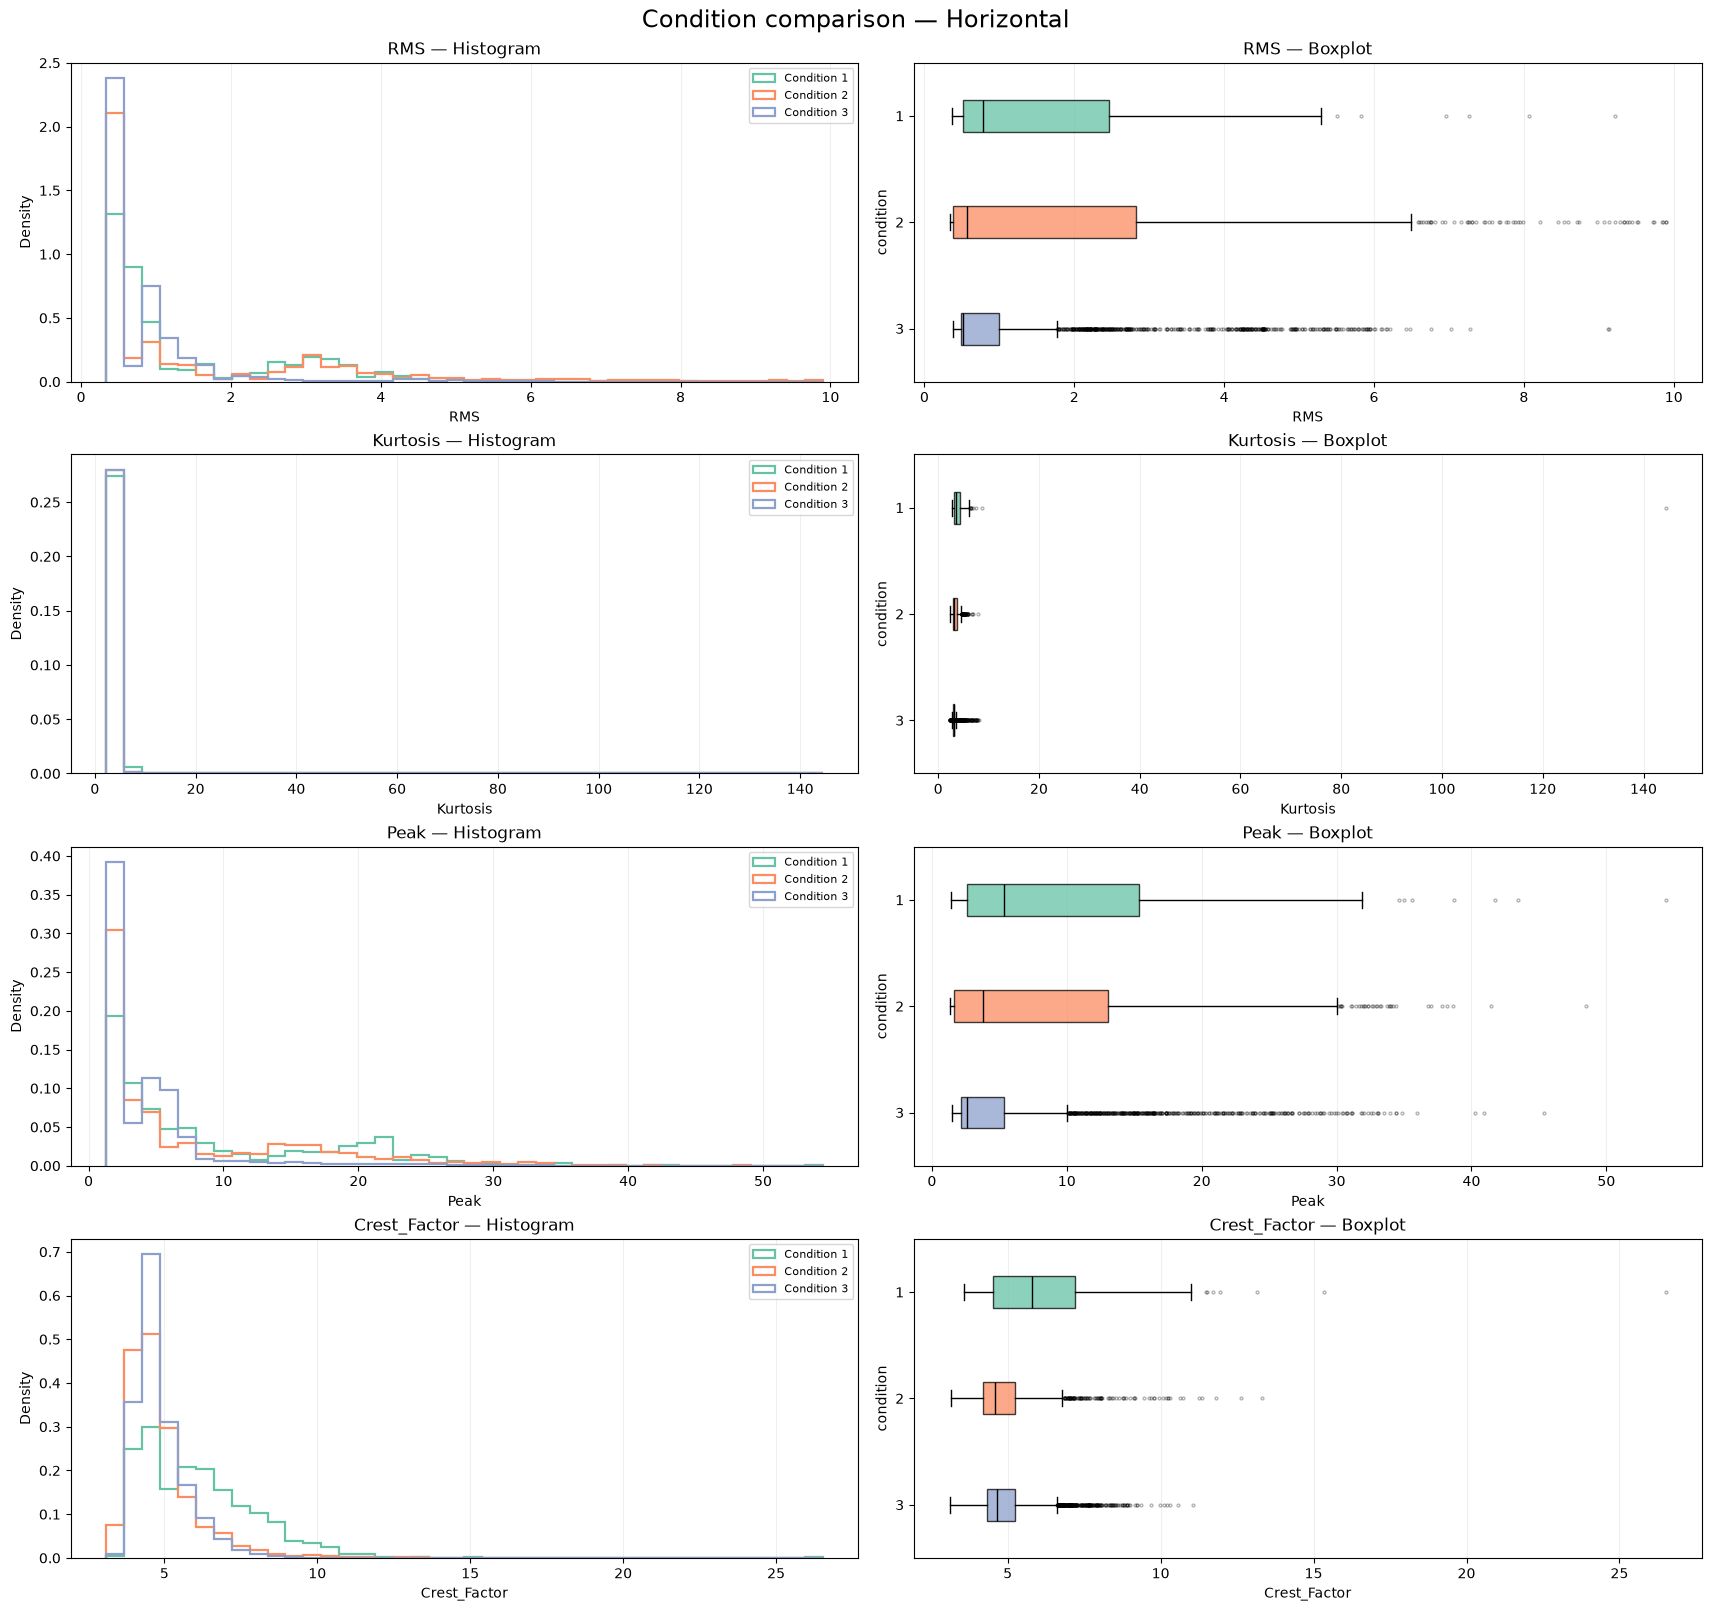

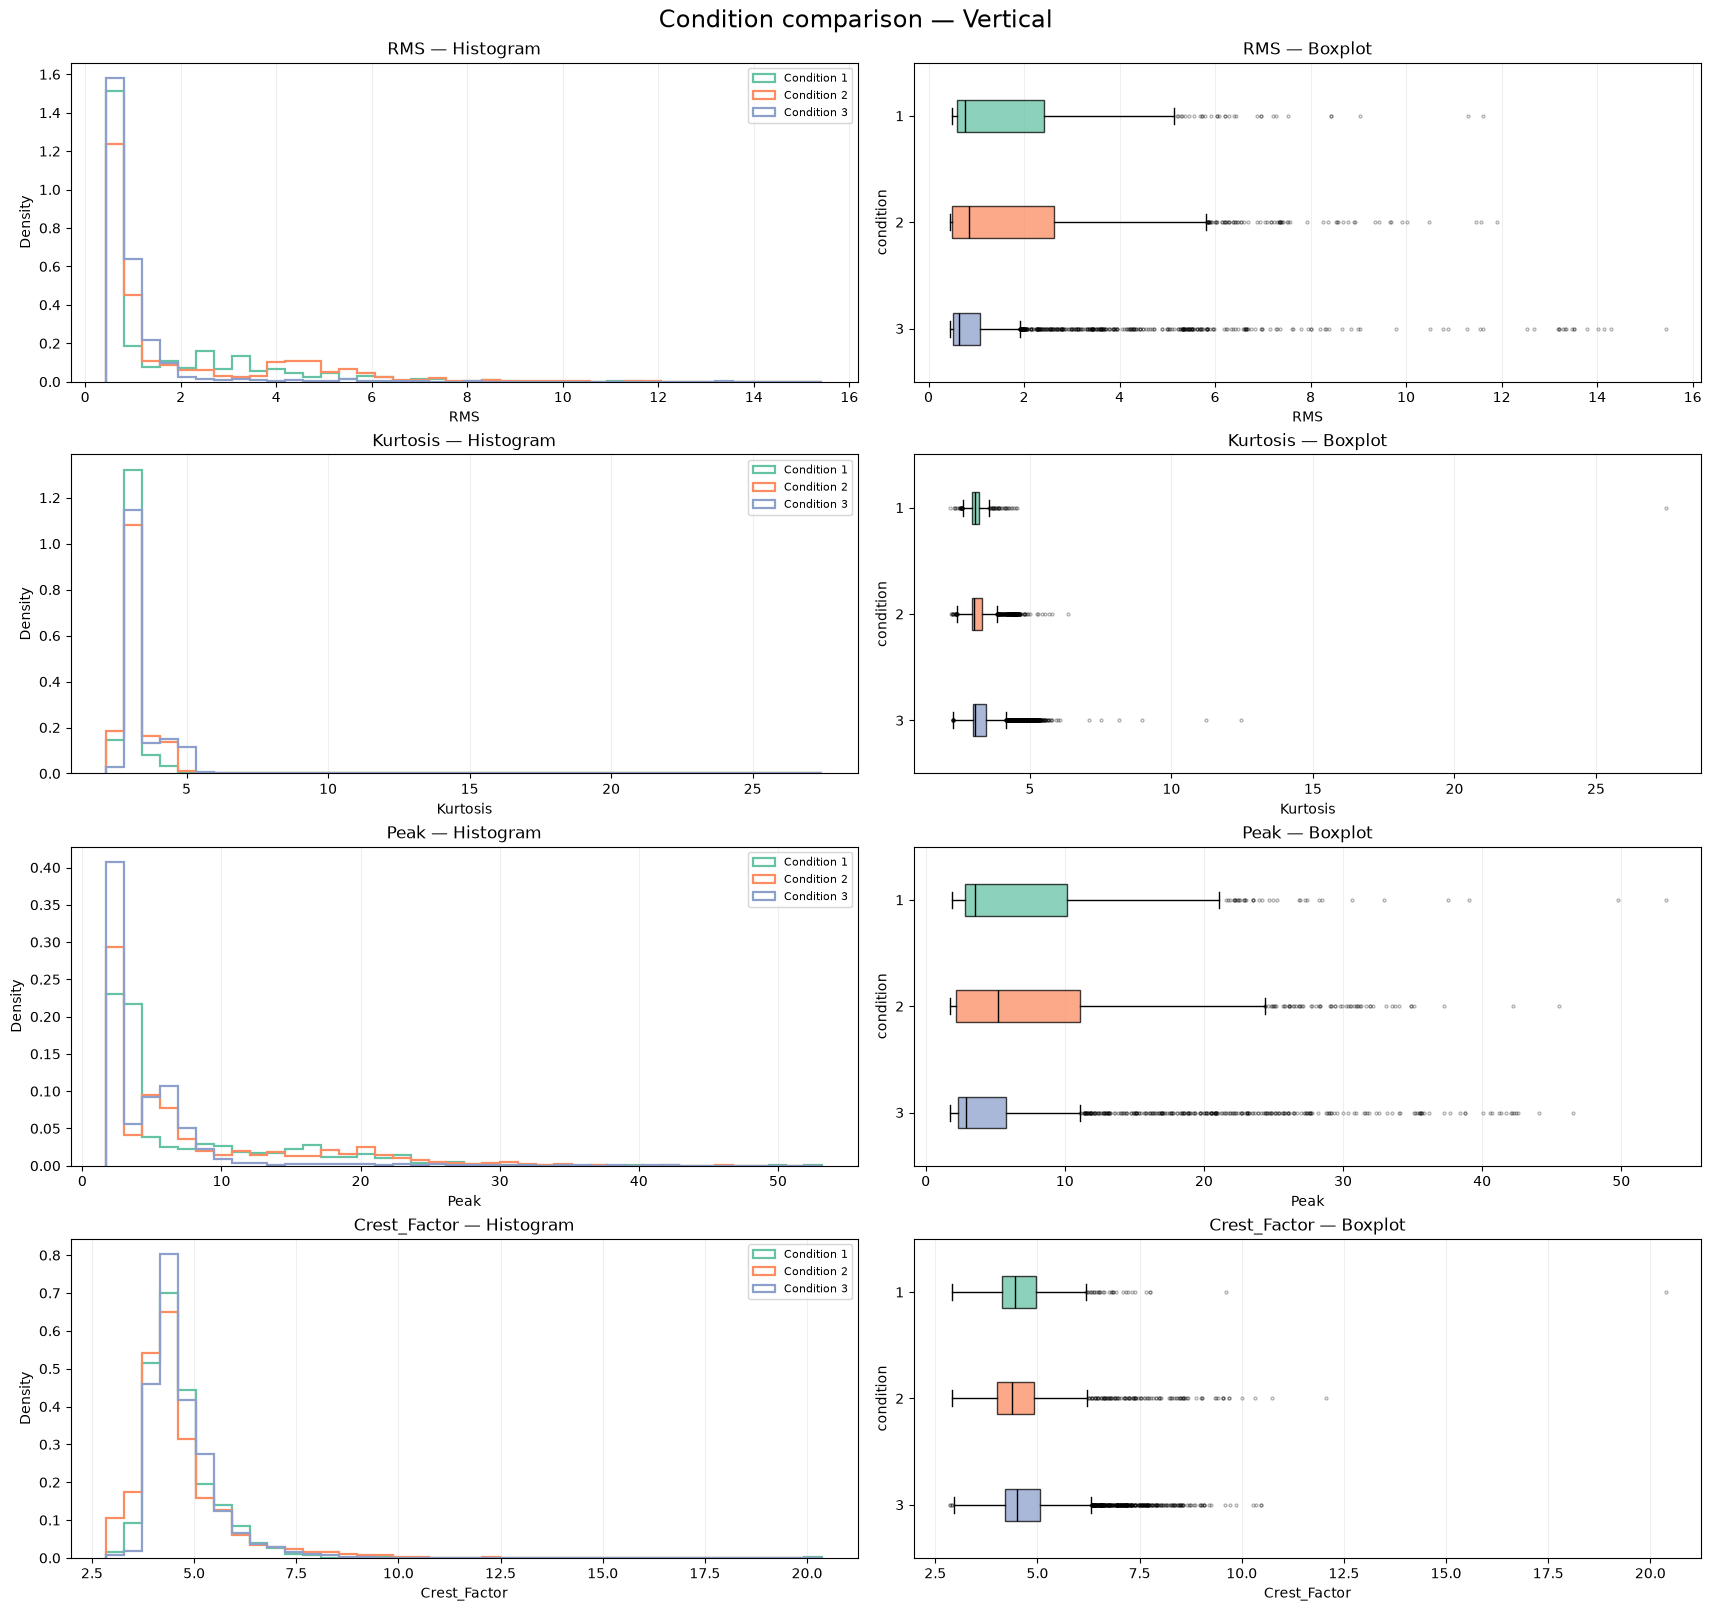

In [ ]:
for direction in DIRECTIONS:
    subset = long_df.loc[long_df["direction"] == direction]
    group_col = "condition"
    group_order = CONDITIONS
    palette = condition_palette

    fig, axes = plt.subplots(4, 2, figsize=(17, 16), constrained_layout=True)
    fig.suptitle(f"Condition comparison — {direction}")

    for row, feature in enumerate(FEATURES):
        feature_df = subset.loc[subset["feature"] == feature]
        ax_hist, ax_box = axes[row]

        if feature_df.empty:
            for ax in (ax_hist, ax_box):
                ax.text(0.5, 0.5, "No valid data", ha="center", transform=ax.transAxes)
            continue

        bins = np.histogram_bin_edges(feature_df["value"].to_numpy(), bins=N_BINS)
        present_groups = []
        box_values = []

        for group_name in group_order:
            values = feature_df.loc[feature_df[group_col] == group_name, "value"].to_numpy()
            if len(values) == 0:
                continue
            present_groups.append(group_name)
            box_values.append(values)
            label = str(group_name)
            if group_col == "condition":
                label = f"Condition {group_name}"
            elif group_col == "fault_element":
                label = fault_labels.get(group_name, str(group_name))

            ax_hist.hist(
                values, bins=bins, density=True, histtype="step",
                linewidth=1.6, color=palette[group_name], label=label,
            )

        boxes = ax_box.boxplot(
            box_values, **BOX_ORIENTATION,
            patch_artist=True, showfliers=True, whis=1.5,
            medianprops={"color": "black"},
            flierprops={"marker": "o", "markersize": 2, "alpha": 0.3},
        )
        for patch, group_name in zip(boxes["boxes"], present_groups):
            patch.set_facecolor(palette[group_name])
            patch.set_alpha(0.75)

        labels = []
        for group_name in present_groups:
            label = str(group_name)
            if group_col == "fault_element":
                label = fault_labels.get(group_name, label)
            labels.append(label)
        ax_box.set_yticks(range(1, len(present_groups) + 1))
        ax_box.set_yticklabels(labels)
        ax_box.invert_yaxis()
        ax_box.set_ylabel(group_col)

        ax_hist.set_title(f"{feature} — Histogram")
        ax_hist.set_ylabel("Density")
        ax_hist.legend(fontsize=8, loc="upper right")
        ax_box.set_title(f"{feature} — Boxplot")
        for ax in (ax_hist, ax_box):
            ax.set_xlabel(feature)
            ax.grid(axis="x", alpha=0.2)

  
    fig.savefig(OUTPUT_DIR_FIGURE / "03_distribution" / f"01_condition_{direction.lower()}.png", dpi=150, bbox_inches="tight")
    plt.show()
    plt.close(fig)


### (2) 측정 방향별 비교 (수평, 수직)
- 측정 방향끼리 비교한다. 
- 비교 집단은 각 Condition으로 함. (Condition별로 측정값의 개수 차이나기 때문)


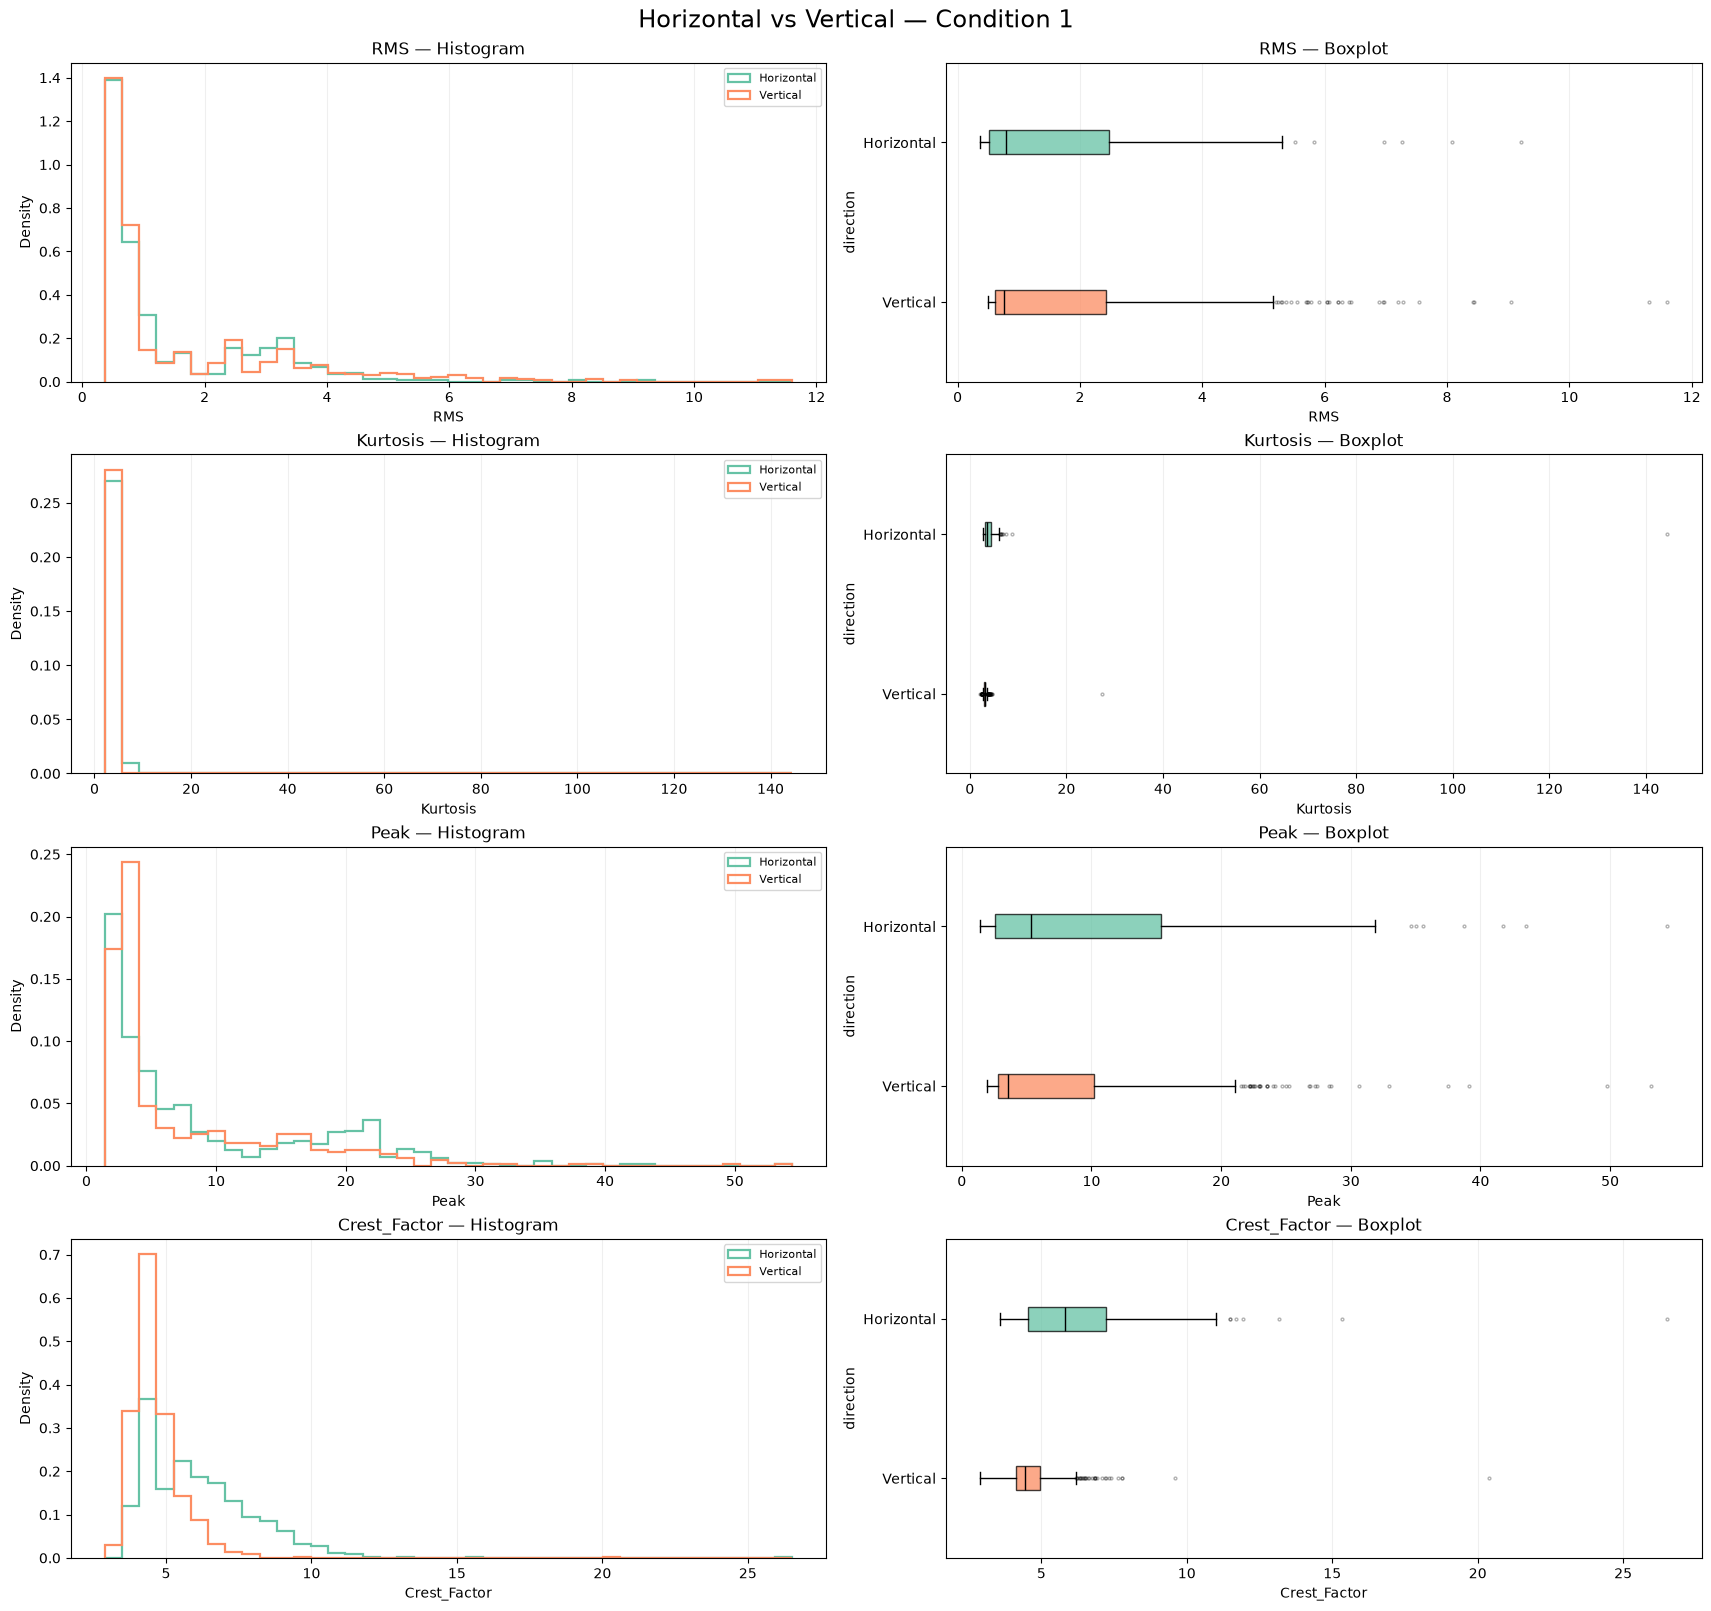

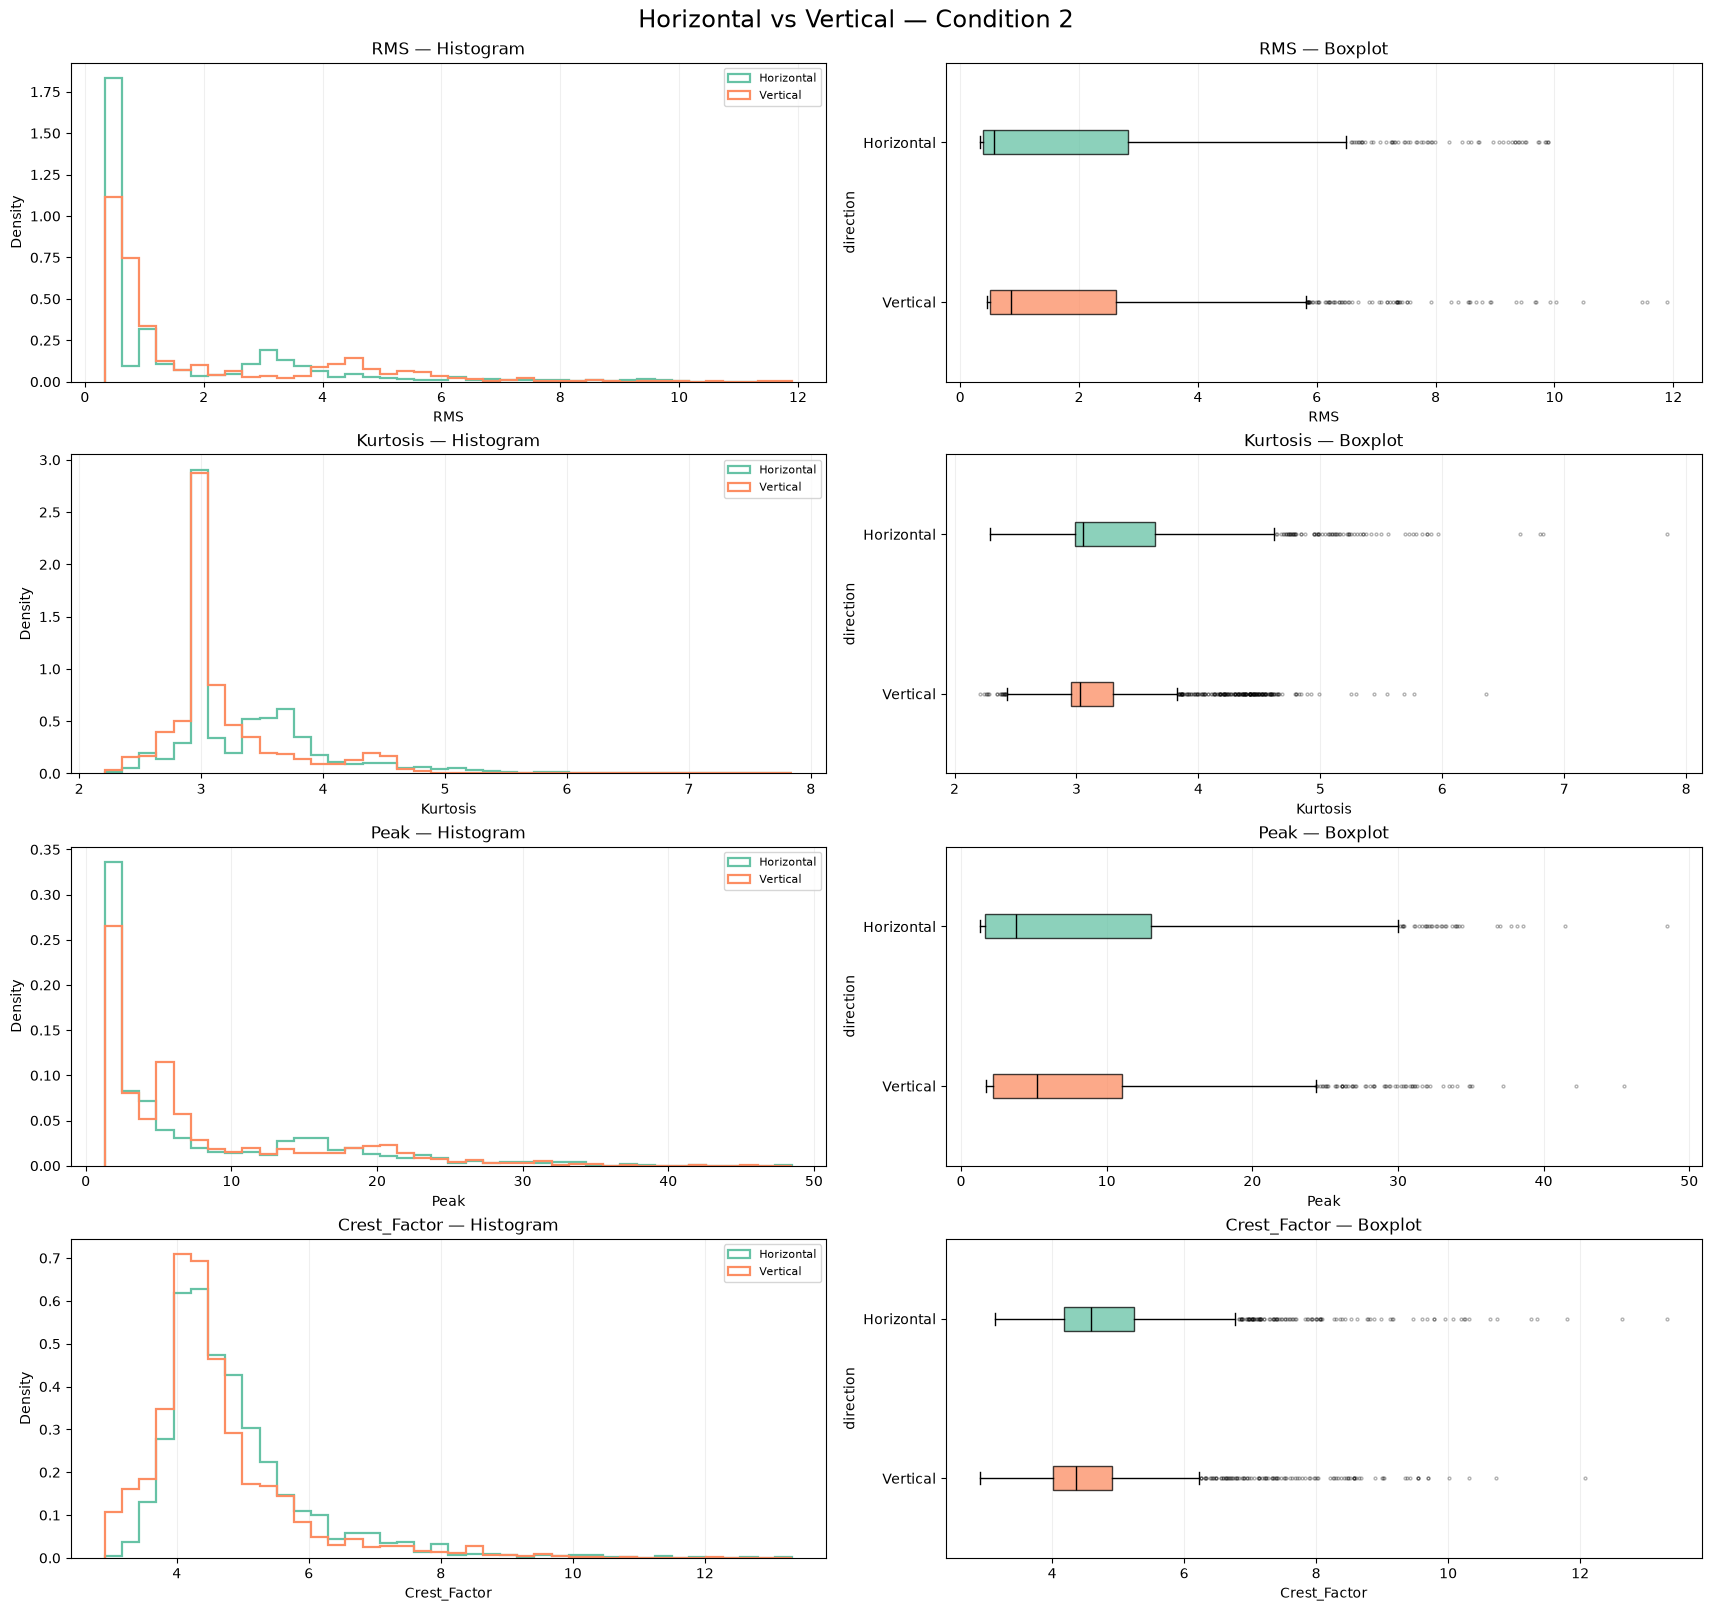

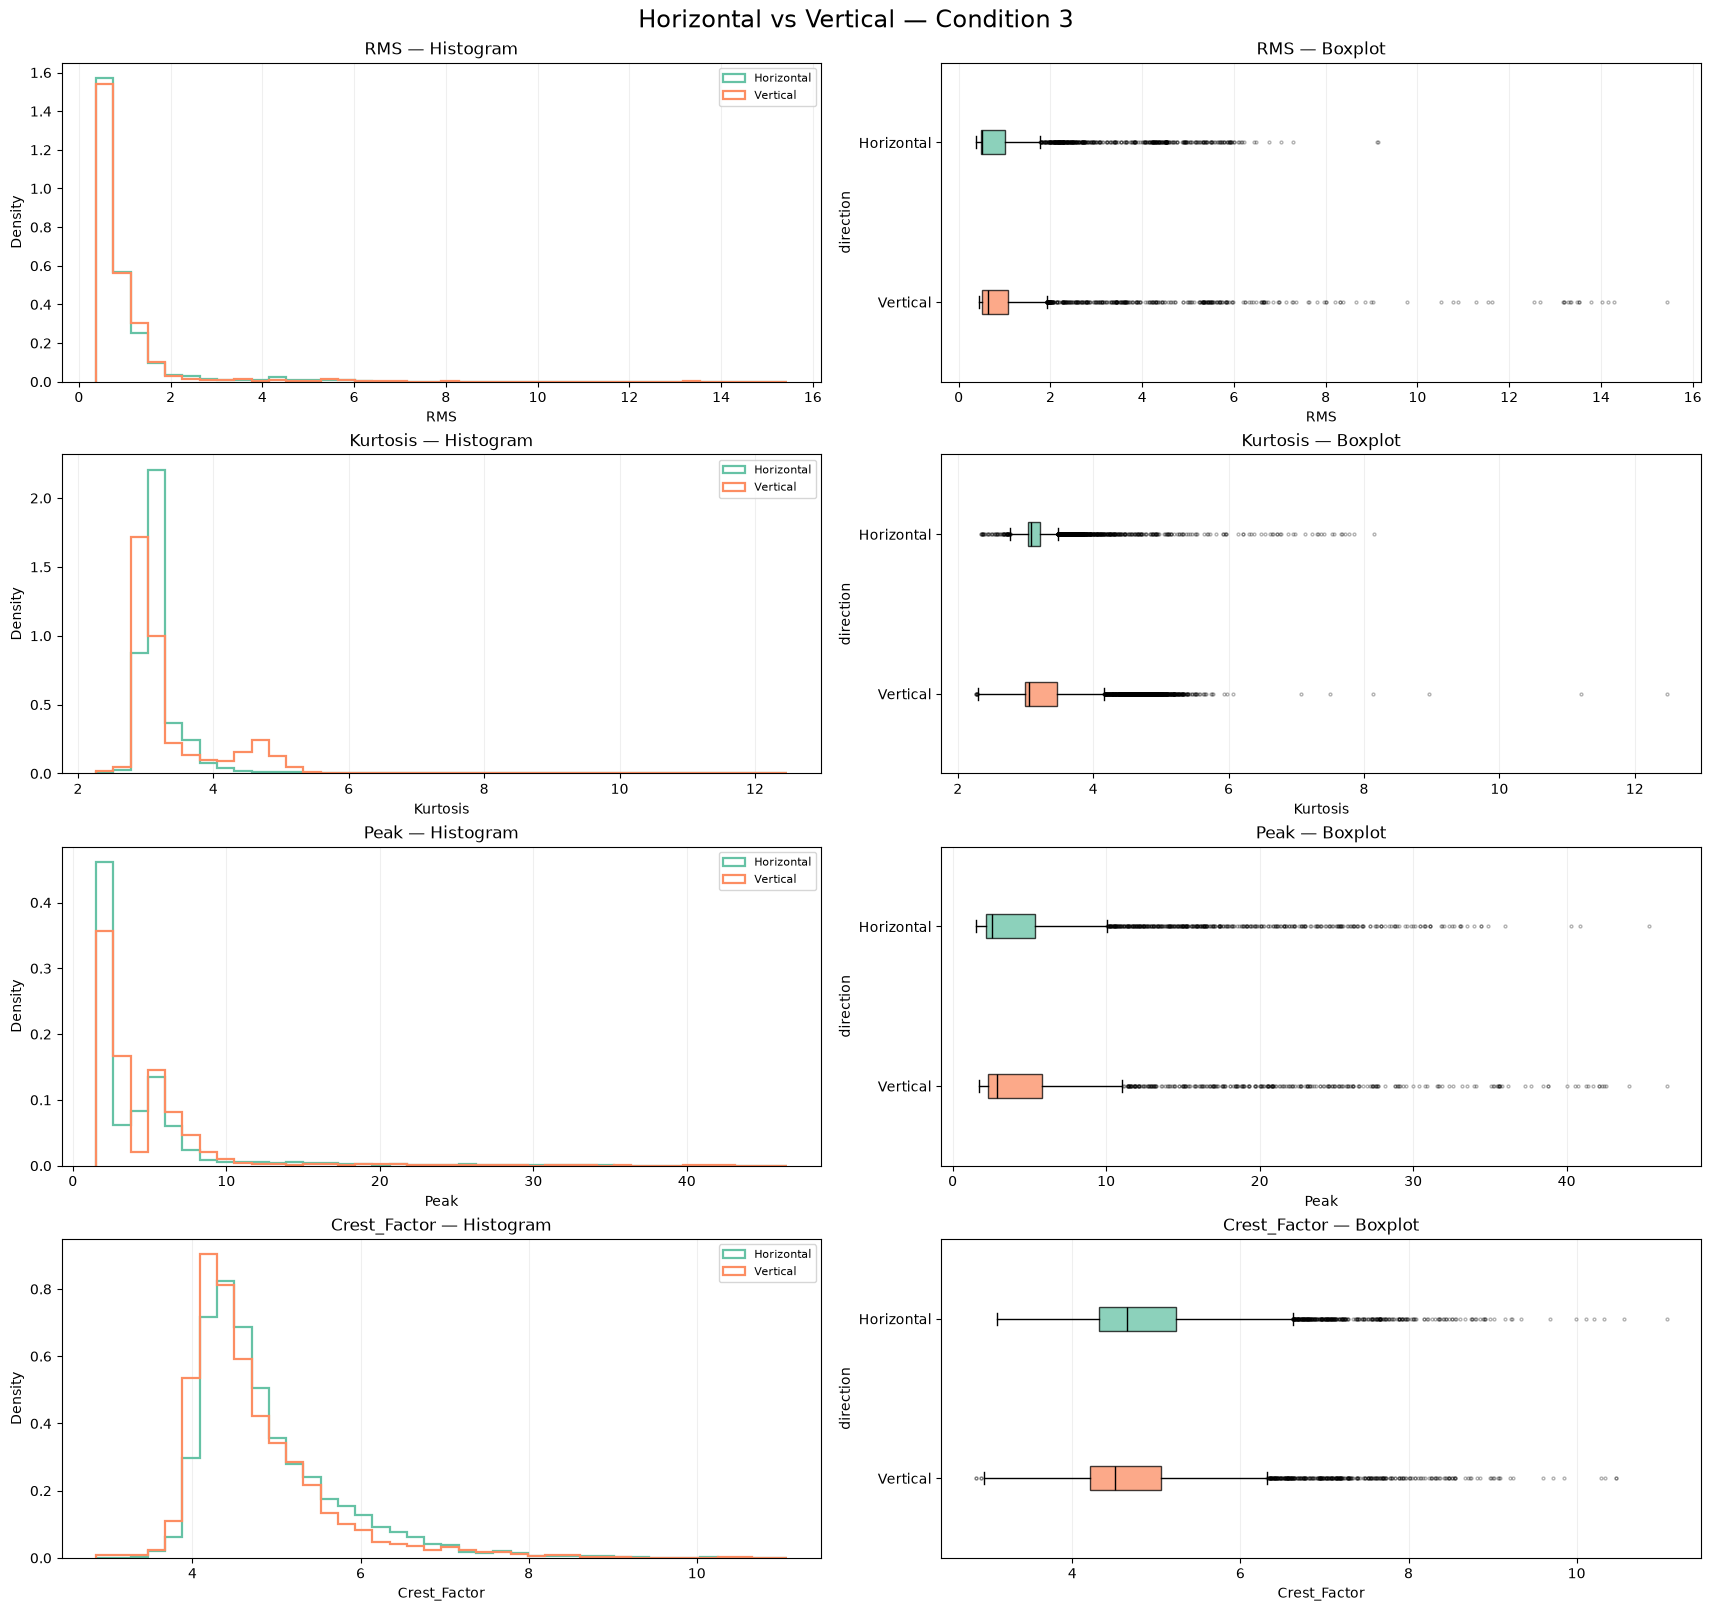

In [ ]:
for condition in CONDITIONS:
    subset = long_df.loc[long_df["condition"] == condition]
    group_col = "direction"
    group_order = DIRECTIONS
    palette = direction_palette

    fig, axes = plt.subplots(4, 2, figsize=(17, 16), constrained_layout=True)
    fig.suptitle(f"Horizontal vs Vertical — Condition {condition}")

    for row, feature in enumerate(FEATURES):
        feature_df = subset.loc[subset["feature"] == feature]
        ax_hist, ax_box = axes[row]

        if feature_df.empty:
            for ax in (ax_hist, ax_box):
                ax.text(0.5, 0.5, "No valid data", ha="center", transform=ax.transAxes)
            continue

        bins = np.histogram_bin_edges(feature_df["value"].to_numpy(), bins=N_BINS)
        present_groups = []
        box_values = []

        for group_name in group_order:
            values = feature_df.loc[feature_df[group_col] == group_name, "value"].to_numpy()
            if len(values) == 0:
                continue
            present_groups.append(group_name)
            box_values.append(values)
            label = str(group_name)
            if group_col == "condition":
                label = f"Condition {group_name}"
            elif group_col == "fault_element":
                label = fault_labels.get(group_name, str(group_name))

            ax_hist.hist(
                values, bins=bins, density=True, histtype="step",
                linewidth=1.6, color=palette[group_name], label=label,
            )

        boxes = ax_box.boxplot(
            box_values, **BOX_ORIENTATION,
            patch_artist=True, showfliers=True, whis=1.5,
            medianprops={"color": "black"},
            flierprops={"marker": "o", "markersize": 2, "alpha": 0.3},
        )
        for patch, group_name in zip(boxes["boxes"], present_groups):
            patch.set_facecolor(palette[group_name])
            patch.set_alpha(0.75)

        labels = []
        for group_name in present_groups:
            label = str(group_name)
            if group_col == "fault_element":
                label = fault_labels.get(group_name, label)
            labels.append(label)
        ax_box.set_yticks(range(1, len(present_groups) + 1))
        ax_box.set_yticklabels(labels)
        ax_box.invert_yaxis()
        ax_box.set_ylabel(group_col)

        ax_hist.set_title(f"{feature} — Histogram")
        ax_hist.set_ylabel("Density")
        ax_hist.legend(fontsize=8, loc="upper right")
        ax_box.set_title(f"{feature} — Boxplot")
        for ax in (ax_hist, ax_box):
            ax.set_xlabel(feature)
            ax.grid(axis="x", alpha=0.2)

    fig.savefig(OUTPUT_DIR_FIGURE / "03_distribution" / f"02_direction_condition{condition}.png", dpi=150, bbox_inches="tight")
    plt.show()
    plt.close(fig)


### (3) 최종 고장 부위별 비교
- 최종 고장 부위별 값의 분포를 비교


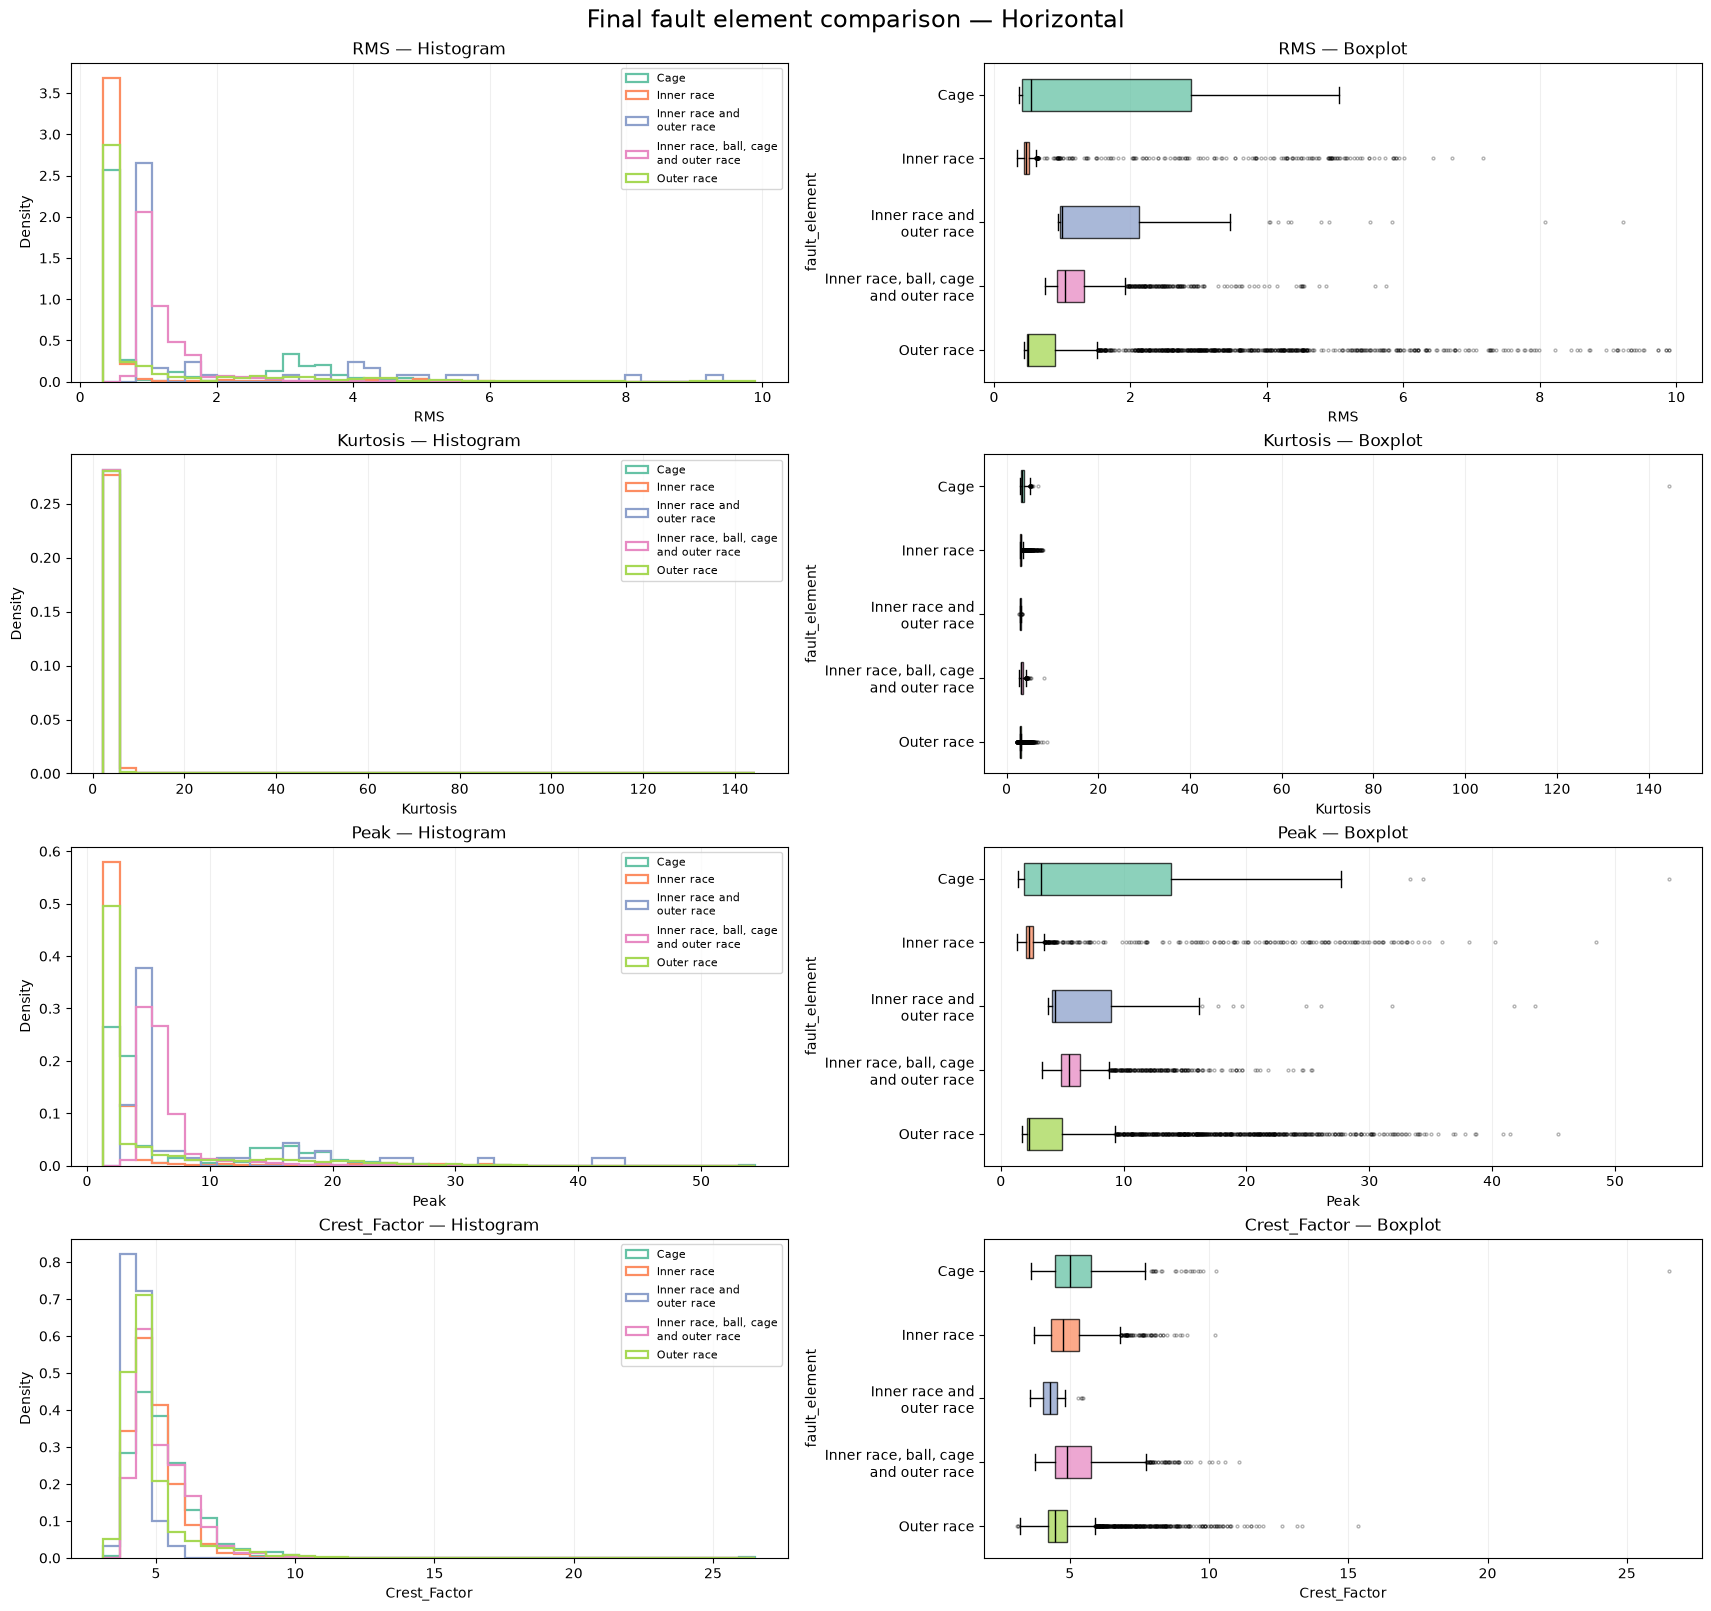

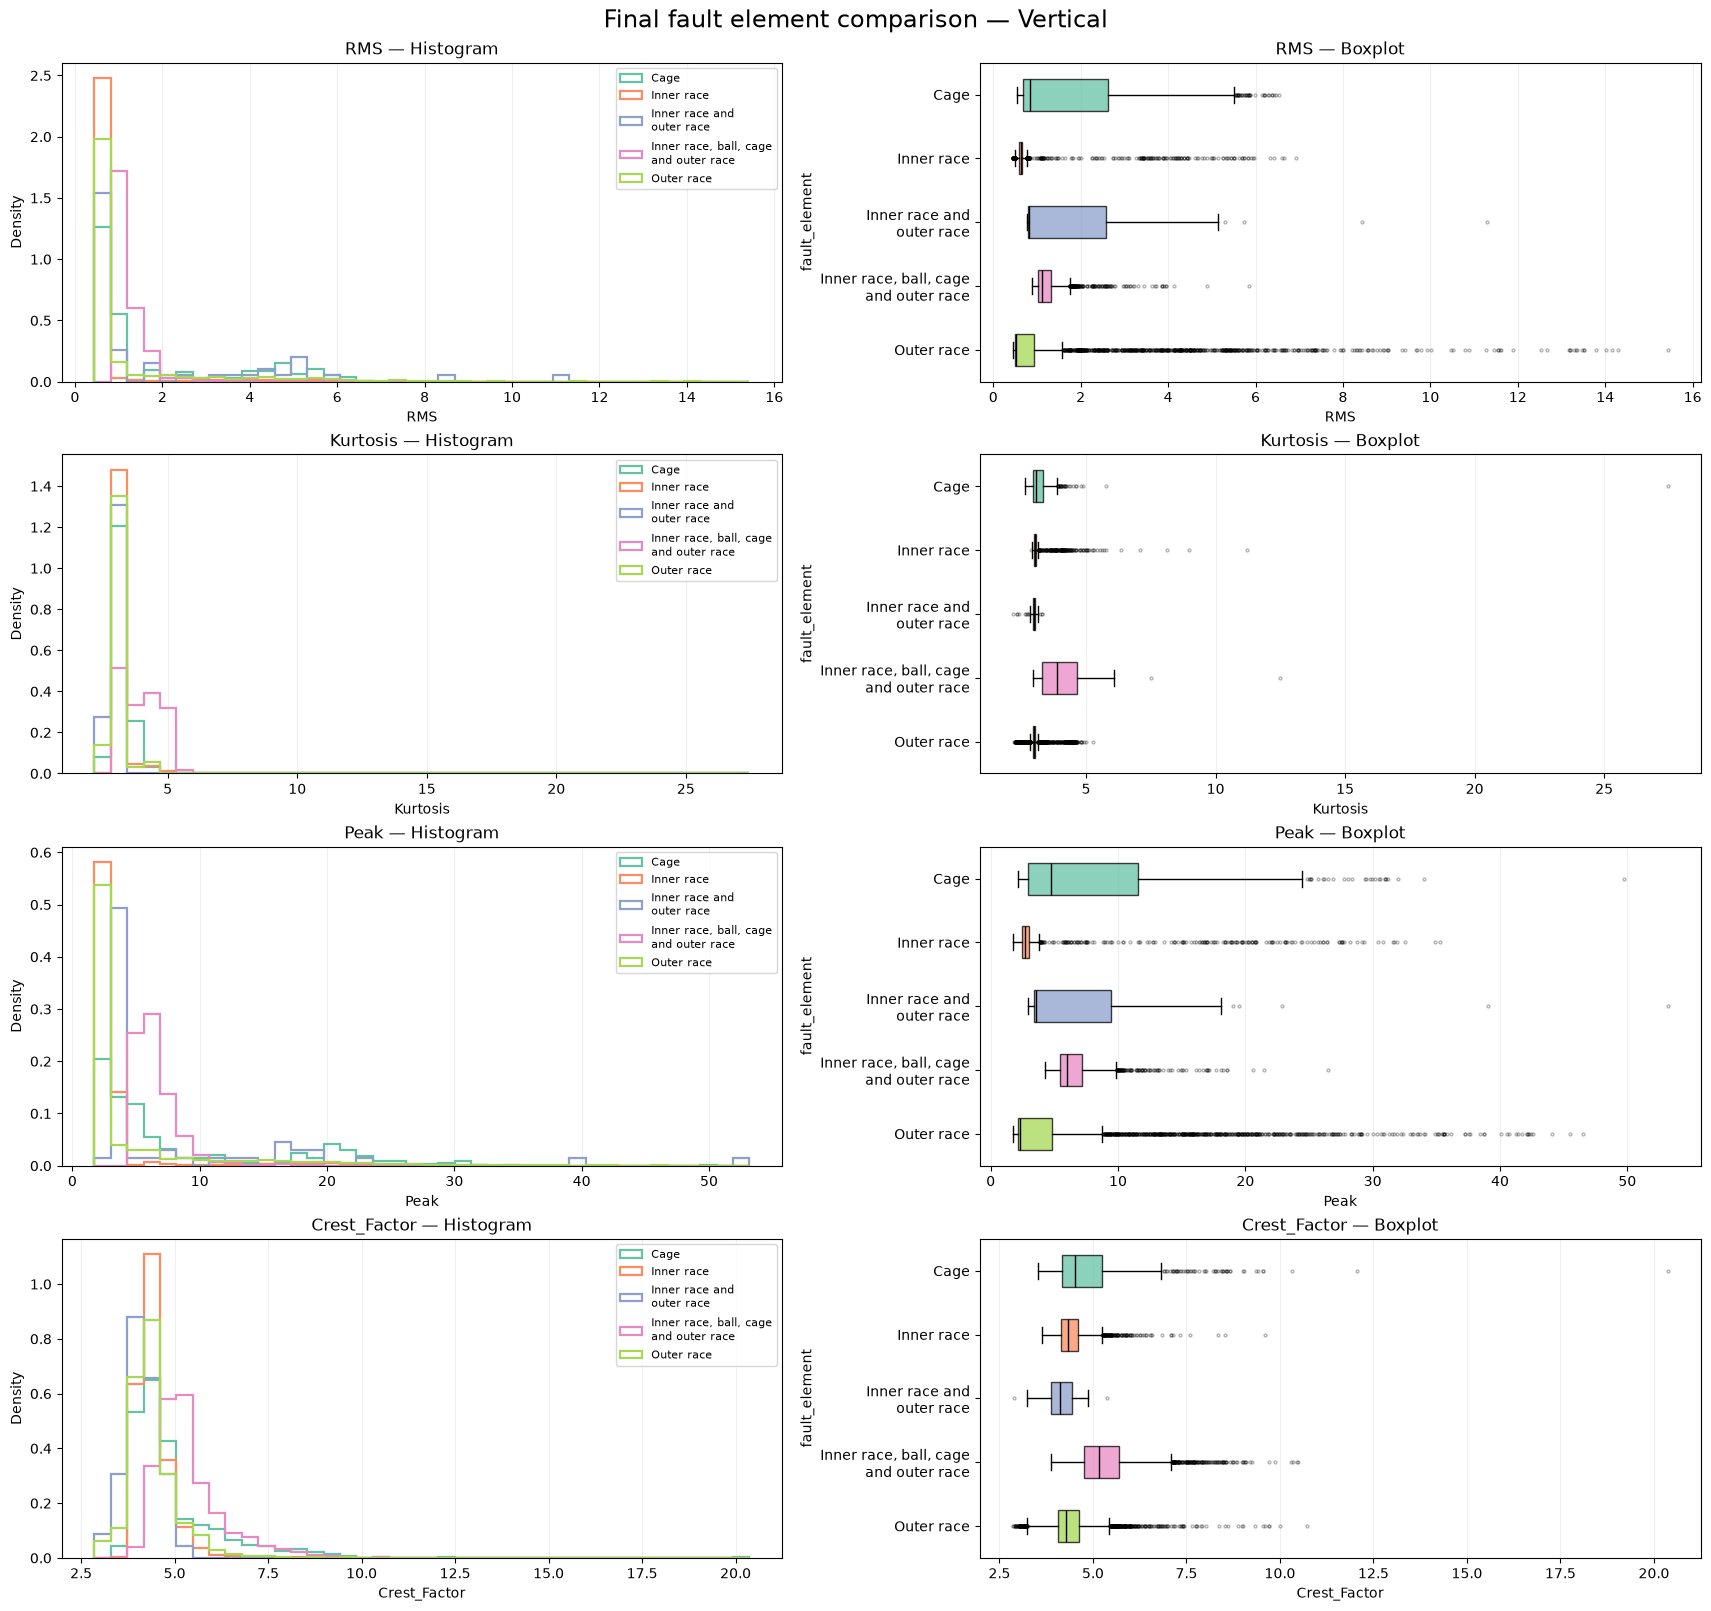

In [ ]:
for direction in DIRECTIONS:
    subset = long_df.loc[long_df["direction"] == direction]
    group_col = "fault_element"
    group_order = FAULTS
    palette = fault_palette

    fig, axes = plt.subplots(4, 2, figsize=(17, 16), constrained_layout=True)
    fig.suptitle(f"Final fault element comparison — {direction}")

    for row, feature in enumerate(FEATURES):
        feature_df = subset.loc[subset["feature"] == feature]
        ax_hist, ax_box = axes[row]

        if feature_df.empty:
            for ax in (ax_hist, ax_box):
                ax.text(0.5, 0.5, "No valid data", ha="center", transform=ax.transAxes)
            continue

        bins = np.histogram_bin_edges(feature_df["value"].to_numpy(), bins=N_BINS)
        present_groups = []
        box_values = []

        for group_name in group_order:
            values = feature_df.loc[feature_df[group_col] == group_name, "value"].to_numpy()
            if len(values) == 0:
                continue
            present_groups.append(group_name)
            box_values.append(values)
            label = str(group_name)
            if group_col == "condition":
                label = f"Condition {group_name}"
            elif group_col == "fault_element":
                label = fault_labels.get(group_name, str(group_name))

            ax_hist.hist(
                values, bins=bins, density=True, histtype="step",
                linewidth=1.6, color=palette[group_name], label=label,
            )

        boxes = ax_box.boxplot(
            box_values, **BOX_ORIENTATION,
            patch_artist=True, showfliers=True, whis=1.5,
            medianprops={"color": "black"},
            flierprops={"marker": "o", "markersize": 2, "alpha": 0.3},
        )
        for patch, group_name in zip(boxes["boxes"], present_groups):
            patch.set_facecolor(palette[group_name])
            patch.set_alpha(0.75)

        labels = []
        for group_name in present_groups:
            label = str(group_name)
            if group_col == "fault_element":
                label = fault_labels.get(group_name, label)
            labels.append(label)
        ax_box.set_yticks(range(1, len(present_groups) + 1))
        ax_box.set_yticklabels(labels)
        ax_box.invert_yaxis()
        ax_box.set_ylabel(group_col)

        ax_hist.set_title(f"{feature} — Histogram")
        ax_hist.set_ylabel("Density")
        ax_hist.legend(fontsize=8, loc="upper right")
        ax_box.set_title(f"{feature} — Boxplot")
        for ax in (ax_hist, ax_box):
            ax.set_xlabel(feature)
            ax.grid(axis="x", alpha=0.2)

    fig.savefig(OUTPUT_DIR_FIGURE / "03_distribution"  / f"03_fault_element_{direction.lower()}.png", dpi=150, bbox_inches="tight")
    plt.show()
    plt.close(fig)


# 4. 시계열 변화 분석

In [ ]:
# timestamp는 날짜가 아닌 측정 순번: 1, 2, 3, ... (측정 간격 1분)
df["timestamp"] = pd.to_numeric(df["timestamp"], errors="raise")
df["condition"] = pd.to_numeric(df["condition"], errors="raise")
df = df.sort_values(["bearing", "timestamp"]).reset_index(drop=True)

In [ ]:
FEATURES = [
    ("rms", "RMS (g)"),
    ("kurtosis", "Kurtosis (Pearson)"),
    ("peak", "Peak (g)"),
    ("crest_factor", "Crest factor"),
]

CHANNELS = [
    ("horizontal", "Horizontal", "tab:blue"),
    ("vertical", "Vertical", "tab:orange"),
]

# 공개 자료의 실험 종료 시점
# timestamp를 1부터 표시하는 현재 CSV 기준
# F는 실험 종료 기준이며, 실제 기능 정지 시점을 뜻하지는 않음
F_TIMES = {
    "Bearing1_1": 123,
    "Bearing1_2": 161,
    "Bearing1_3": 158,
    "Bearing1_4": 122,
    "Bearing1_5": 52,
    "Bearing2_1": 491,
    "Bearing2_2": 161,
    "Bearing2_3": 533,
    "Bearing2_4": 42,
    "Bearing2_5": 339,
    "Bearing3_1": 2538,
    "Bearing3_2": 2496,
    "Bearing3_3": 371,
    "Bearing3_4": 1515,
    "Bearing3_5": 114,
}

# 데이터에 있는 전체 베어링 목록
bearings = sorted(df["bearing"].dropna().unique())

### (1) 기본 특징값 시계열 그래프

In [ ]:
# 기본 시계열 그래프

def plot_bearings(data, bearings):
    # 문자열 하나 또는 베어링 이름 리스트를 모두 입력 가능
    if isinstance(bearings, str):
        bearings = [bearings]

    if not bearings:
        raise ValueError("선택된 베어링이 없습니다.")

    missing = [
        bearing for bearing in bearings
        if bearing not in data["bearing"].unique()
    ]
    if missing:
        raise ValueError(f"CSV에 없는 베어링입니다: {missing}")

    n = len(bearings)

    fig, axes = plt.subplots(
        4,
        n,
        figsize=(12 if n == 1 else 4 * n, 10),
        sharex=True,
        # sharey="row"  # 같은 특징의 크기를 베어링끼리 비교하기 좋음
        sharey=False,  # 각 그래프가 독립된 Y축을 사용해 개별 추세를 보기 좋음
        squeeze=False,
    )

    for col, bearing in enumerate(bearings):
        part = (
            data.loc[data["bearing"] == bearing]
            .sort_values("timestamp")
        )
        info = part.iloc[0]
        f_time = F_TIMES[bearing]

        axes[0, col].set_title(
            f"{bearing}\n"
            f"{int(info['rpm'])} rpm / {int(info['load_kn'])} kN"
            f" / F = {f_time} min",
            fontsize=11,
        )

        for row, (feature, ylabel) in enumerate(FEATURES):
            ax = axes[row, col]

            for channel, label, color in CHANNELS:
                ax.plot(
                    part["timestamp"],
                    part[f"{channel}_{feature}"],
                    color=color,
                    linewidth=1.1,
                    label=label,
                )

            ax.axvline(
                f_time,
                color="gray",
                linestyle="--",
                linewidth=1.2,
                label="F (experiment endpoint)",
            )

            if col == 0:
                ax.set_ylabel(ylabel)

            ax.grid(alpha=0.25)
            ax.set_axisbelow(True)

        axes[-1, col].set_xlabel("Measurement time (min; timestamp)")

    # 같은 그림에서는 시간축 범위와 특징별 Y축 범위를 맞춤
    max_f = max(F_TIMES[bearing] for bearing in bearings)
    axes[-1, 0].set_xlim(0, max_f * 1.04)

    handles, labels = axes[0, 0].get_legend_handles_labels()

    fig.suptitle("XJTU-SY | Feature trends", fontsize=15, y=0.995)
    fig.legend(
        handles,
        labels,
        loc="upper center",
        bbox_to_anchor=(0.5, 0.97),
        ncol=3,
        frameon=False,
    )

    fig.tight_layout(rect=(0, 0, 1, 0.91))
    return fig

총 15개 베어링 그래프 저장 완료


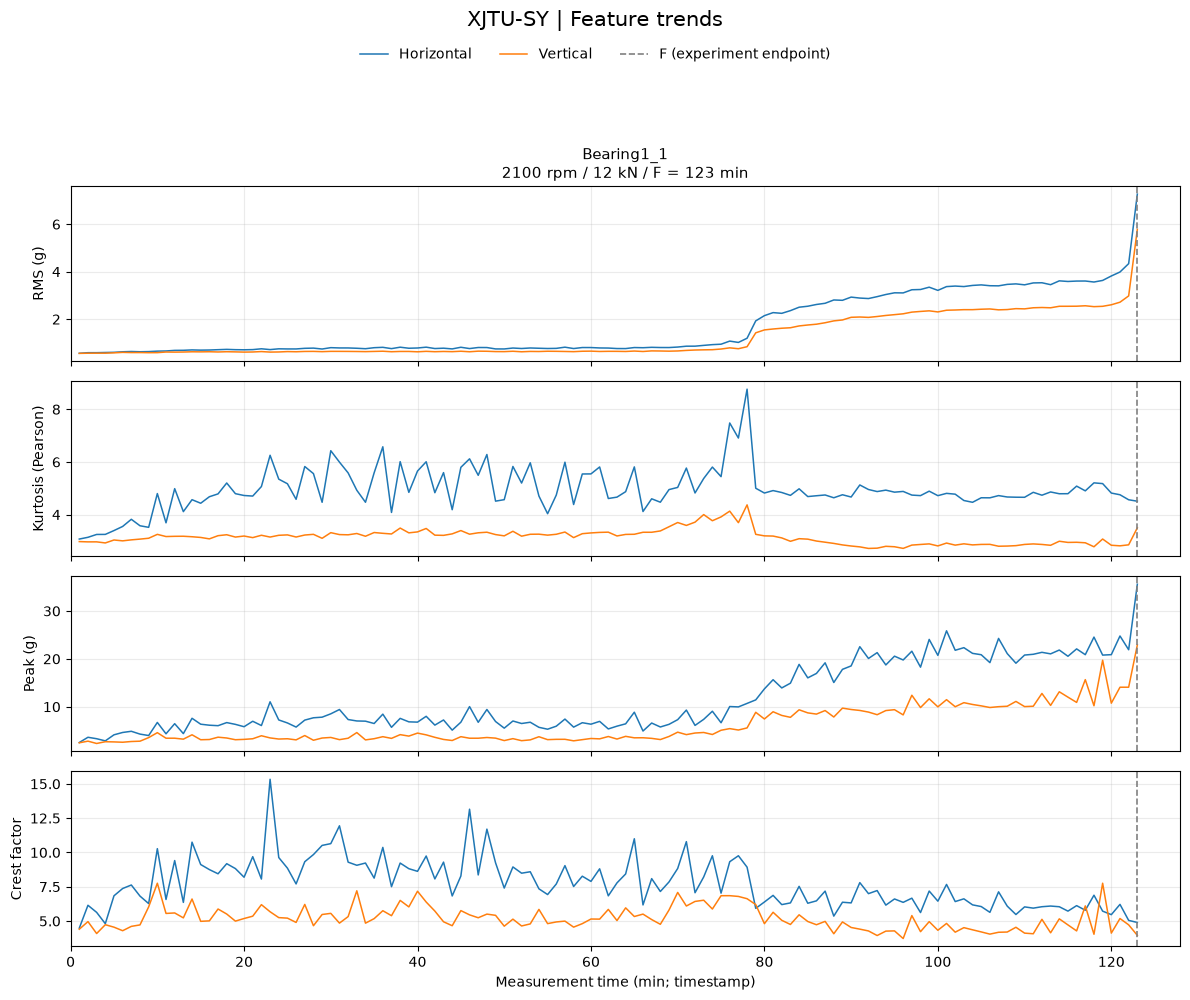

In [ ]:
(OUTPUT_DIR_FIGURE / "04_time_series" / "01_feature_trend").mkdir(parents=True, exist_ok=True)

for bearing in bearings:
    fig = plot_bearings(df, bearing)

    fig.savefig(
        OUTPUT_DIR_FIGURE / "04_time_series" / "01_feature_trend" / f"{bearing}.png",
        dpi=150,
        bbox_inches="tight",
    )
    plt.close(fig)

print(f"총 {len(bearings)}개 베어링 그래프 저장 완료")

bearing = "Bearing1_1" # 베어링 이름 입력하는 곳

plot_bearings(df, bearing)
plt.show()

### (2) 이동평균 시계열 그래프

초기 상태 / 변화 후보 구간 / 변화한 특징 / 순간적·지속적 변화 여부 / 수평·수직 차이


전체 → 초기 → 변화 후보 구간 순서로 출력

In [ ]:
# 이동평균에 사용할 측정값 개수
window = 5

# True: 전체 구간 그래프도 출력
# False: 지정한 변화 구간 그래프만 출력
show_full = True

# 변화 후보 구간 
# Bearing1_1 ~ Bearing3_5 순서로 변화 구간 입력
# 한 줄이 베어링 하나에 해당하며, 구간끼리는 공백으로 구분
# "40 -52"처럼 하이픈 주변에 공백이 있어도 처리 가능
interval_text = """
1-35 30-70 65-90 85-123
1-35 20-50 35-80 120-140
1-40 40-85 120-158
1-45 40-85 75-121
1-32 28-43 40 -52

1-100 90-440 430-470 460-491
1-50 40-70 70-100 95-145 140-161
1-150 120-255 240-330 315-390 380-460 450-533
1-20 15-32 28-42
1-130 110-180 170-235 225-290 280-339

1-300 250-1200 1150-2250 2200-2400 2380-2490 2480-2538
1-300 250-750 700-1200 1150-1750 1700-2250 2200-2400 2380-2496
1-80 70-250 240-340 330-355 350-371
1-300 250-900 850-1150 1100-1420 1400-1460 1450-1515
1-25 20-55 50-75 70-95 90-114
"""

# 숫자로 입력한 변화 구간을 딕셔너리로 변환
lines = [
    line.strip()
    for line in interval_text.splitlines()
    if line.strip()
]

if len(lines) != len(bearings):
    raise ValueError(
        f"변화 구간은 베어링별로 {len(bearings)}줄이어야 합니다. "
        f"현재 {len(lines)}줄입니다."
    )

change_ranges = {}

for bearing, line in zip(bearings, lines):
    # 하이픈 주변의 공백 제거
    normalized = re.sub(r"\s*-\s*", "-", line)

    ranges = []
    for token in normalized.split():
        if not re.fullmatch(r"\d+(?:\.\d+)?-\d+(?:\.\d+)?", token):
            raise ValueError(f"{bearing}: 잘못된 구간 형식입니다: {token}")

        start, end = map(float, token.split("-"))

        if start >= end:
            raise ValueError(f"{bearing}: 시작 시점은 종료 시점보다 작아야 합니다.")

        ranges.append((start, end))

    change_ranges[bearing] = ranges


def prepare_bearing(df, bearing):
    """베어링 데이터를 시간순으로 정렬하고 전체 구간 이동평균 계산."""
    part = (
        df.loc[df["bearing"] == bearing]
        .sort_values("timestamp")
        .copy()
    )

    if part.empty:
        raise ValueError(f"{bearing}: 데이터가 없습니다.")

    for channel, _, _ in CHANNELS:
        for feature, _ in FEATURES:
            col = f"{channel}_{feature}"

            part[f"{col}_ma"] = part[col].rolling(
                window=window,
                min_periods=window,
                center=False,
            ).mean()

    return part

In [ ]:
# 이동평균 그래프
def plot_trends(part, bearing, f_time, start=None, end=None):
    """전체 구간 또는 지정한 변화 구간의 원본값과 이동평균 표시."""

    # 전체 데이터의 실제 측정 시작·종료 시점
    full_start = part["timestamp"].min()
    full_end = part["timestamp"].max()

    start = full_start if start is None else start
    end = full_end if end is None else end

    view = part.loc[part["timestamp"].between(start, end)]

    if view.empty:
        raise ValueError(
            f"{bearing}: {start:g}–{end:g}분 구간에 데이터가 없습니다."
        )

    fig, axes = plt.subplots(
        len(FEATURES), 1,
        figsize=(12, 10),
        sharex=True,
        sharey=False,
    )

    for ax, (feature, ylabel) in zip(axes, FEATURES):
        for channel, label, color in CHANNELS:
            col = f"{channel}_{feature}"

            # 원본 특징값
            ax.plot(
                view["timestamp"],
                view[col],
                color=color,
                alpha=0.35,
                linewidth=1,
                label=f"{label} raw",
            )

            # 전체 데이터에서 미리 계산한 이동평균
            ax.plot(
                view["timestamp"],
                view[f"{col}_ma"],
                color=color,
                linewidth=1.8,
                label=f"{label} MA{window}",
            )

        # 실험 종료 시점이 표시 구간 안에 있을 때만 수직선 표시
        if start <= f_time <= end:
            ax.axvline(
                f_time,
                color="gray",
                linestyle="--",
                label="F (experiment endpoint)",
            )

        ax.set_ylabel(ylabel)
        ax.grid(alpha=0.25)

    axes[0].legend(ncol=3, fontsize=9)
    axes[-1].set_xlabel("Measurement time (min; timestamp)")

    # 데이터가 한 시점뿐인 경우에도 축 범위 확보
    margin = (end - start) * 0.02 if end > start else 1
    axes[-1].set_xlim(start, end + margin)

    # 확대 그래프에서도 원래 전체 측정 범위를 확인 가능
    fig.suptitle(
        f"{bearing} | Raw + MA{window}\n"
        f"Full data: {full_start:g}–{full_end:g} min | "
        f"View: {start:g}–{end:g} min | F: {f_time:g} min",
        fontsize=13,
    )

    fig.tight_layout(rect=(0, 0, 1, 0.93))
    return fig


In [ ]:
# 모든 베어링을 순서대로 반복
for bearing, ranges in change_ranges.items():
    (OUTPUT_DIR_FIGURE / "04_time_series" / "02_ma5_trend" / bearing).mkdir(parents=True, exist_ok=True)

    # 일부 베어링 데이터가 없어도 나머지는 계속 출력
    if not df["bearing"].eq(bearing).any():
        print(f"[건너뜀] {bearing}: 데이터가 없습니다.")
        continue

    if bearing not in F_TIMES:
        print(f"[건너뜀] {bearing}: F_TIMES에 종료 시점이 없습니다.")
        continue

    part = prepare_bearing(df, bearing)
    f_time = F_TIMES[bearing]

    full_start = part["timestamp"].min()
    full_end = part["timestamp"].max()

    # 전체 구간 그래프
    if show_full:
        fig = plot_trends(part, bearing, f_time)
        fig.savefig(
                OUTPUT_DIR_FIGURE / "04_time_series" / "02_ma5_trend" / bearing / f"{bearing}_full.png",
                dpi=150,
                bbox_inches="tight",
            )
        plt.close(fig)

    # 지정한 변화 구간 그래프
    for start, end in ranges:
        if not part["timestamp"].between(start, end).any():
            print(f"[건너뜀] {start:g}–{end:g}분: 데이터가 없습니다.")
            continue

        fig = plot_trends(
            part,
            bearing,
            f_time,
            start=start,
            end=end,
        )
        fig.savefig(
                OUTPUT_DIR_FIGURE / "04_time_series" / "02_ma5_trend" / bearing / f"{bearing}_{int(start)}_{int(end)}.png",
                dpi=150,
                bbox_inches="tight",
            )
        plt.close(fig)

print("04_time_series/02_ma5_trend 에 저장완료")

04_time_series/02_ma5_trend 에 저장완료


# 5. 특징간 관계 분석

### (1) 특징값 상관계수 그래프

In [ ]:
# 상관계수 계산 방법
# pearson: 선형 관계를 확인
# spearman: 값의 순위를 이용하여 함께 증가·감소하는 관계를 확인
method = "pearson"

# 히트맵 축에 표시할 특징 이름
labels = ["RMS", "Kurtosis", "Peak", "Crest factor"]

(OUTPUT_DIR_FIGURE / "05_feature_relationship" / "01_pearson_correlation").mkdir(parents=True, exist_ok=True)


# 베어링별로 반복
for bearing in bearings:

    # 현재 베어링의 전체 데이터 선택
    part = (
        df.loc[df["bearing"] == bearing]
        .sort_values("timestamp")
        .copy()
    )

    full_start = part["timestamp"].min()
    full_end = part["timestamp"].max()

    # 수평·수직 채널의 히트맵을 1행 2열로 배치
    # constrained_layout=True: 제목·축·색상 막대의 간격 자동 조절   
    fig, axes = plt.subplots(
        1, 2,
        figsize=(11, 4.5),
        constrained_layout=True,
    )

    # 각 그래프 축에 수평·수직 채널을 하나씩 연결
    # 히트맵에는 채널별 선 색상이 필요 없으므로 _로 받음
    for ax, (channel, label, _) in zip(axes, CHANNELS):

        # 현재 채널의 원본 특징 컬럼 4개 선택
        # _ma가 붙은 이동평균 컬럼은 포함하지 않음
        cols = [
            f"{channel}_{feature}"
            for feature, _ in FEATURES
        ]

        # 특징 두 개씩의 상관계수를 계산하여 4×4 표 생성
        # 현재 선택한 베어링의 전체 기간을 사용
        corr = part[cols].corr(method=method)

        # 상관계수 표를 색으로 표현
        # vmin, vmax를 고정하여 두 채널의 색상 기준을 통일
        # RdBu_r: 음수는 파랑, 양수는 빨강 계열
        im = ax.imshow(
            corr,
            vmin=-1,
            vmax=1,
            cmap="RdBu_r",
        )

        # X축과 Y축에 특징 이름 표시
        # rotation=30: X축 글자를 30도 기울여 겹침 방지
        # ha="right": X축 글자를 오른쪽 기준으로 정렬
        ax.set_xticks(
            range(len(labels)),
            labels,
            rotation=30,
            ha="right",
        )
        ax.set_yticks(range(len(labels)), labels)

        # 각 히트맵 제목에 채널 이름 표시
        ax.set_title(label)

        # 각 칸에 상관계수 표시
        for row in range(len(labels)):
            for col in range(len(labels)):
                value = corr.iloc[row, col]

                # text(X위치, Y위치, 표시할 내용)
                # .2f: 소수점 둘째 자리까지 표시
                #
                # 색이 진한 칸에는 흰 글씨를 사용해 가독성 확보
                # 0.6은 글씨 색상을 고르는 기준일 뿐,
                # 고장 판단 기준은 아님
                ax.text(
                     col, row,
                     f"{value:.2f}",
                     ha="center",
                     va="center",
                     color="white" if abs(value) > 0.6 else "black",
                )

    # 두 채널에 공통 색상 막대 적용
    fig.colorbar(
        im,
        ax=axes,
        label="Correlation",
        shrink=0.8,
    )

    # 전체 측정 시간도 제목에 표시
    fig.suptitle(
        f"{bearing}: {method.title()} correlation (raw, full period)\n"
    )

    fig.savefig(
                    OUTPUT_DIR_FIGURE / "05_feature_relationship" / "01_pearson_correlation" / f"{bearing}.png",
                    dpi=150,
                    bbox_inches="tight",
                )

    plt.close(fig)

print("05_feature_relationship/01_pearson_correlation 에 저장완료")

05_feature_relationship/01_pearson_correlation 에 저장완료


### (2) 특징값 관계 산점도 
 - RMS와 Peak, Kurtosis의 관계를 알아본다. 

In [ ]:
(OUTPUT_DIR_FIGURE / "05_feature_relationship" / "02_feature_relationships").mkdir(parents=True, exist_ok=True)

# 베어링별로 반복
for bearing in bearings:


    # X축은 RMS로 고정하고, Y축으로 비교할 특징 설정
    # 첫 번째 행: RMS와 Peak
    # 두 번째 행: RMS와 첨도
    pairs = [
        ("peak", "Peak (g)"),
        ("kurtosis", "Kurtosis (Pearson)"),
    ]

    # 2행 2열 그래프 생성
    # 왼쪽 열: 수평 채널
    # 오른쪽 열: 수직 채널
    fig, axes = plt.subplots(
        2, 2,
        figsize=(11, 8),
        constrained_layout=True,
    )

    # enumerate(): 데이터와 함께 순서 번호를 가져옴
    # col=0은 수평 채널, col=1은 수직 채널
    for col, (channel, label, _) in enumerate(CHANNELS):

        # row=0은 Peak, row=1은 첨도
        for row, (feature, ylabel) in enumerate(pairs):

            # 현재 행·열에 해당하는 그래프 선택
            ax = axes[row, col]

            # 원본 특징값으로 산점도 생성
            # 점 하나는 동일한 측정 파일에서 구한 RMS와 다른 특징의 쌍
            points = ax.scatter(
                part[f"{channel}_rms"],       # X축: RMS
                part[f"{channel}_{feature}"], # Y축: Peak 또는 첨도

                # 측정 시점에 따라 점 색상을 다르게 지정
                c=part["timestamp"],
                cmap="viridis",

                # 네 그래프 모두 동일한 시간-색상 기준 사용
                vmin=part["timestamp"].min(),
                vmax=part["timestamp"].max(),

                s=28,        # 점 크기
                alpha=0.85,  # 점 투명도
            )

            # 축 이름과 채널 제목 설정
            ax.set_xlabel("RMS (g)")
            ax.set_ylabel(ylabel)
            ax.set_title(label)

            # 연한 격자 표시
            ax.grid(alpha=0.2)

    # 점 색상이 어떤 측정 시점에 해당하는지 표시
    # ravel(): 2×2 형태의 axes를 1차원으로 펼침
    # tolist(): 펼친 축들을 파이썬 리스트로 변환
    fig.colorbar(
        points,
        ax=axes.ravel().tolist(),
        label="Measurement time (min)",
        shrink=0.85,
    )

    fig.suptitle(
        f"{bearing}: Feature relationships (raw, full period)"
    )


    fig.savefig(
                    OUTPUT_DIR_FIGURE / "05_feature_relationship" / "02_feature_relationships" / f"{bearing}.png",
                    dpi=150,
                    bbox_inches="tight",
                )

    plt.close(fig)

print("05_feature_relationship/02_feature_relationships 에 저장완료")


05_feature_relationship/02_feature_relationships 에 저장완료
